<a href="https://colab.research.google.com/github/ChintiaDeviRoslian/UAS-BIG-DATA/blob/main/US_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Analisis Karakteristik 5V pada Dataset

1. Volume: Pada sample dataset ini mencakup 500.000 baris data dengan 46 kolom yang mencakup data kecelakaan di seluruh Amerika Serikat dari tahun 2016 hingga 2023.
2. Velocity: Secara teknis, data ini adalah data historis. Meskipun data aslinya dikumpulkan secara real-time oleh penyedia data API, dataset yang ada di Kaggle ini bersifat statis dan hanya diperbarui secara berkala, sehingga tidak memiliki karakteristik kecepatan aliran data yang kontinu dalam penggunaan saat ini.
3. Variety: Dataset ini memiliki variasi data yang kaya, mencakup data numerik, kategorikal, boolean, dan temporal. Adanya integrasi antara data lalu lintas dan data cuaca menunjukkan variabilitas sumber data yang berbeda.
4. Veracity: Dataset ini memiliki banyak missing values pada kolom-kolom tertentu. Mengelola ketidakpastian ini adalah bagian penting dari analisis untuk memastikan "kebenaran" hasil analisis.
5. Value: Data ini memiliki nilai strategis tinggi untuk meningkatkan keselamatan jalan raya, memprediksi lokasi rawan kecelakaan, membantu manajemen respons darurat, serta memberikan wawasan bagi perusahaan asuransi atau pengembang teknologi smart city.






In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/US_Accidents_March23_sampled_500k.csv')
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,...,False,False,False,False,False,False,Night,Night,Night,Night


#Struktur dan Karakteristik Data

In [ ]:
df.shape

(500000, 46)

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  object 
 1   Source                 500000 non-null  object 
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  object 
 4   End_Time               500000 non-null  object 
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                279623 non-null  float64
 8   End_Lng                279623 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            499999 non-null  object 
 11  Street                 499309 non-null  object 
 12  City                   499981 non-null  object 
 13  County                 500000 non-null  object 
 14  State                  500000 non-nu

None

In [ ]:
target = df.select_dtypes(include=['int64']).columns.tolist()
numerik = df.select_dtypes(include=['float64']).columns.tolist()
kategorikal = df.select_dtypes(include=['object']).columns.tolist()
boolean = df.select_dtypes(include=['bool']).columns.tolist()

feature_summary = pd.DataFrame({
    'Feature Category': ['Target', 'Numerik', 'Kategorikal', 'Boolean'],
    'Columns': [target, numerik, kategorikal, boolean]
})

display(feature_summary)

,Feature Category,Columns
0,Target,[Severity]
1,Numerik,"[Start_Lat, Start_Lng, End_Lat, End_Lng, Dista..."
2,Kategorikal,"[ID, Source, Start_Time, End_Time, Description..."
3,Boolean,"[Amenity, Bump, Crossing, Give_Way, Junction, ..."


In [ ]:
severity_counts = df['Severity'].value_counts().sort_index() # Keep original order for printing
severity_pct = df['Severity'].value_counts(normalize=True).sort_index() * 100

print("\nSeverity Distribution:")
for severity, count in severity_counts.items():
    pct = severity_pct[severity]
    print(f"• Severity {severity}: {count:,} ({pct:.2f}%)")

severity_df = pd.DataFrame({'Severity': severity_counts.index, 'Count': severity_counts.values})
fig = px.bar(severity_df, x='Severity', y='Count',
             title='Distribusi Tingkat Keparahan Kecelakaan (1-4)',
             labels={'Severity': 'Severity', 'Count': 'Jumlah Kecelakaan'},
             color='Count', # Map color to 'Count' for intensity
             color_continuous_scale='YlOrRd') # Use a continuous red/orange scale
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()


Severity Distribution:
• Severity 1: 4,274 (0.85%)
• Severity 2: 398,142 (79.63%)
• Severity 3: 84,520 (16.90%)
• Severity 4: 13,064 (2.61%)


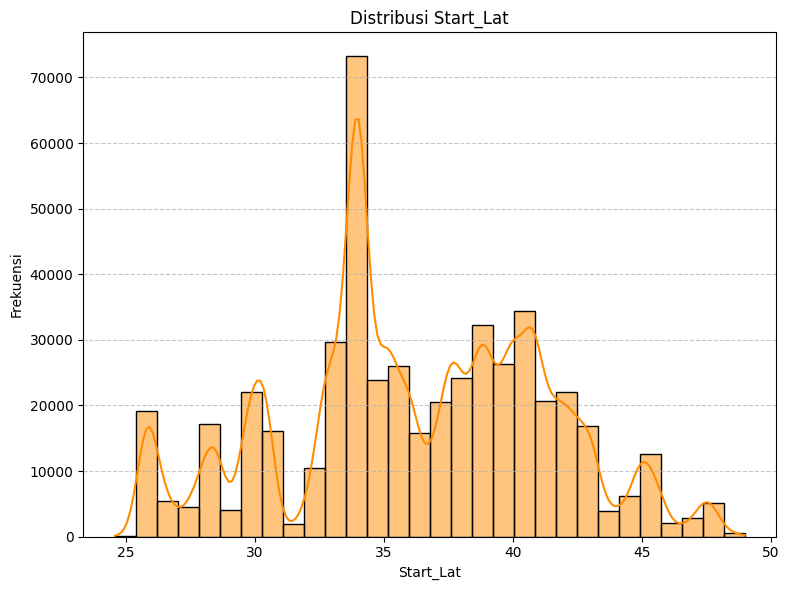

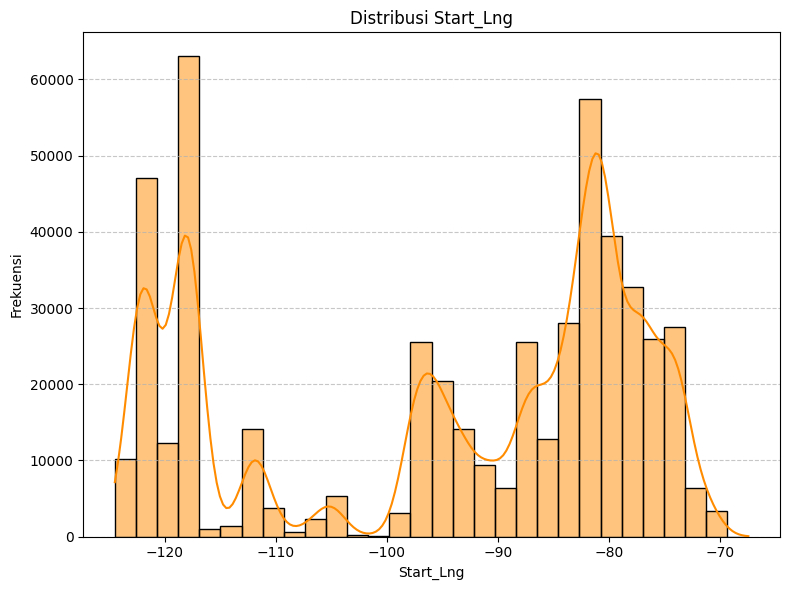

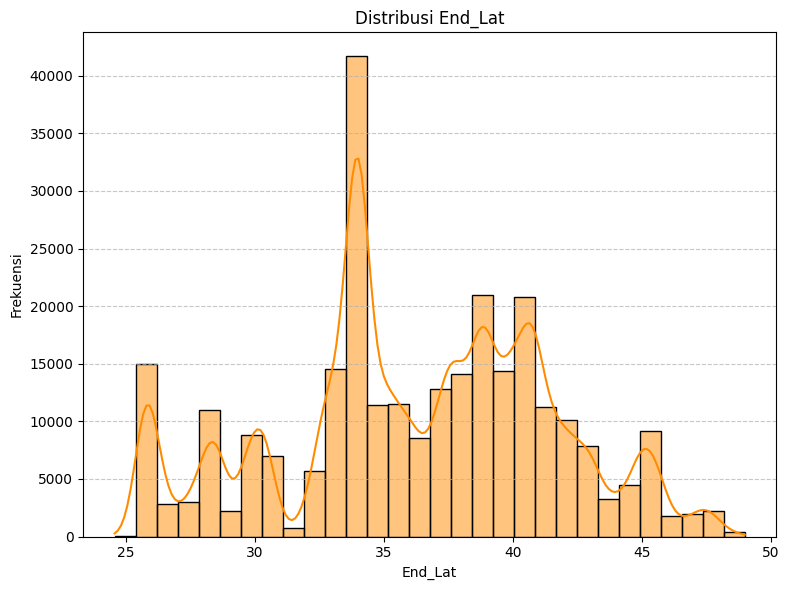

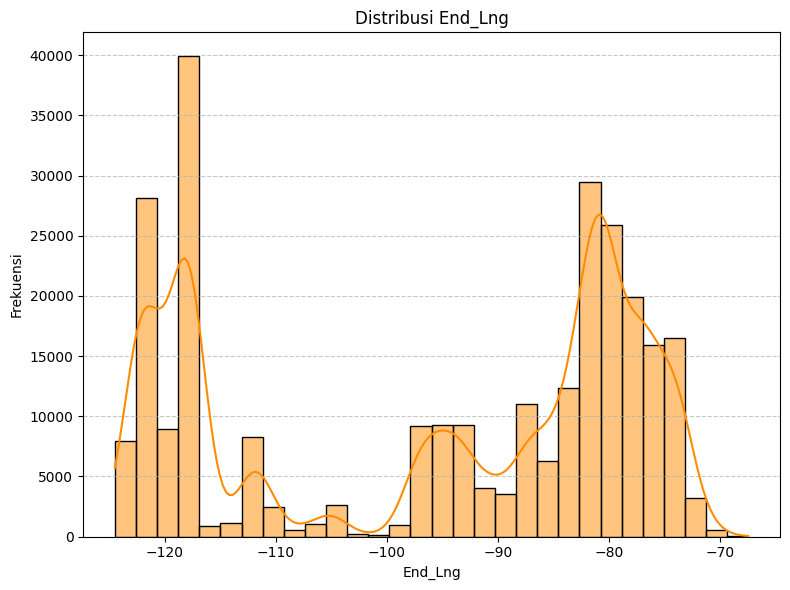

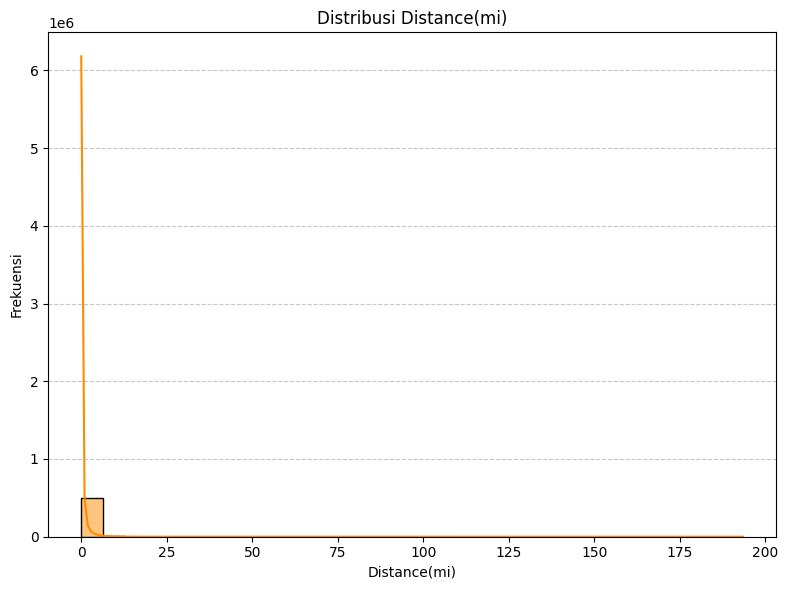

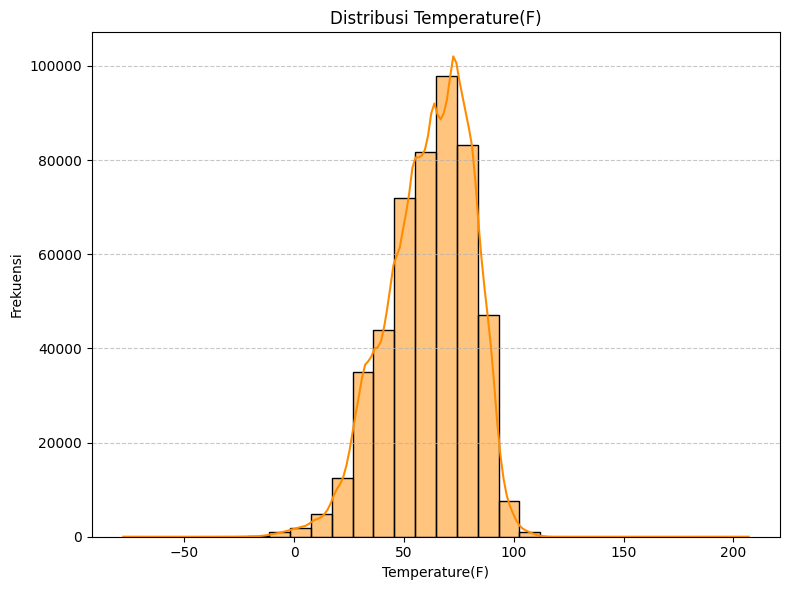

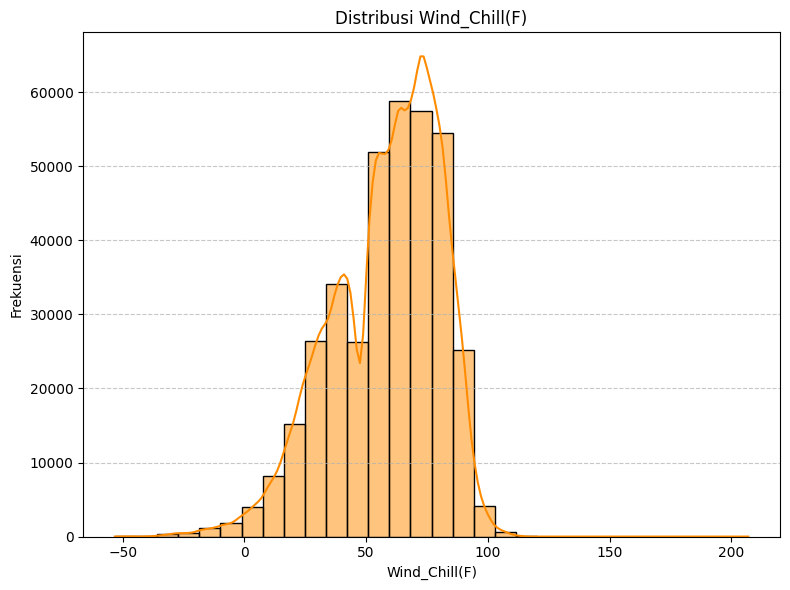

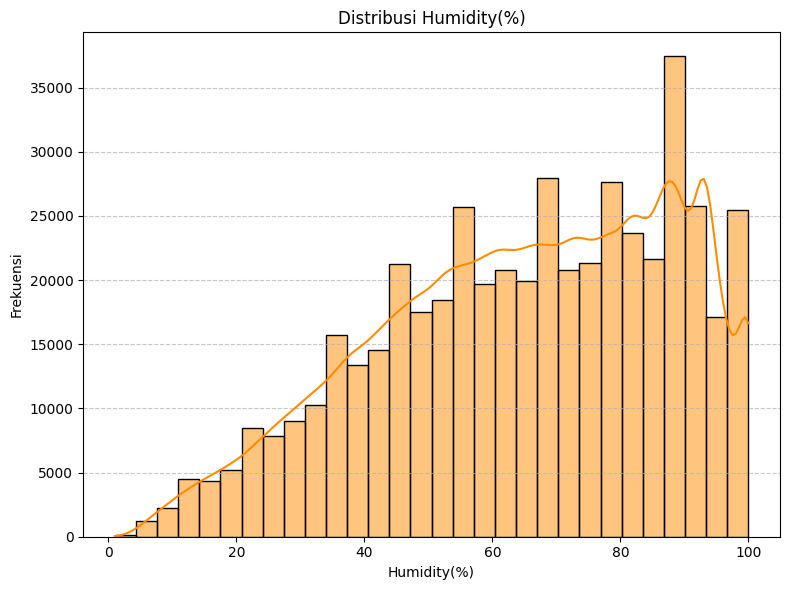

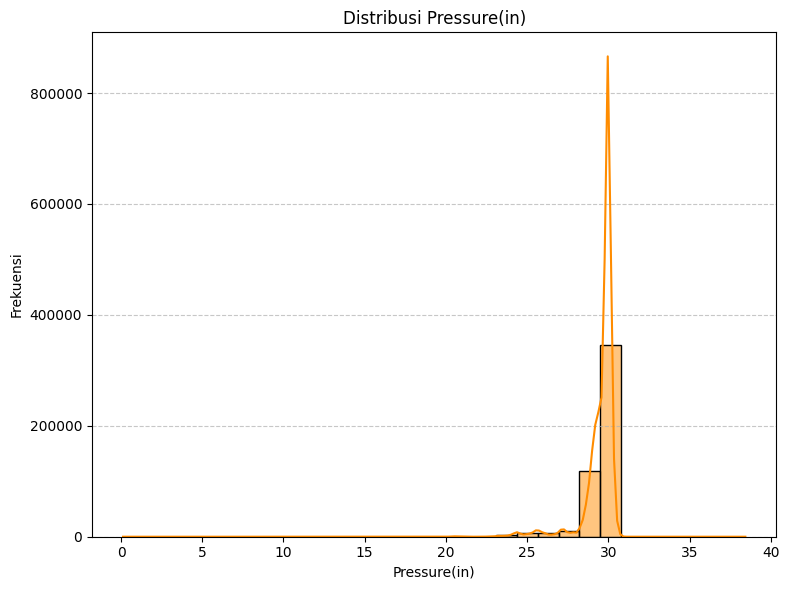

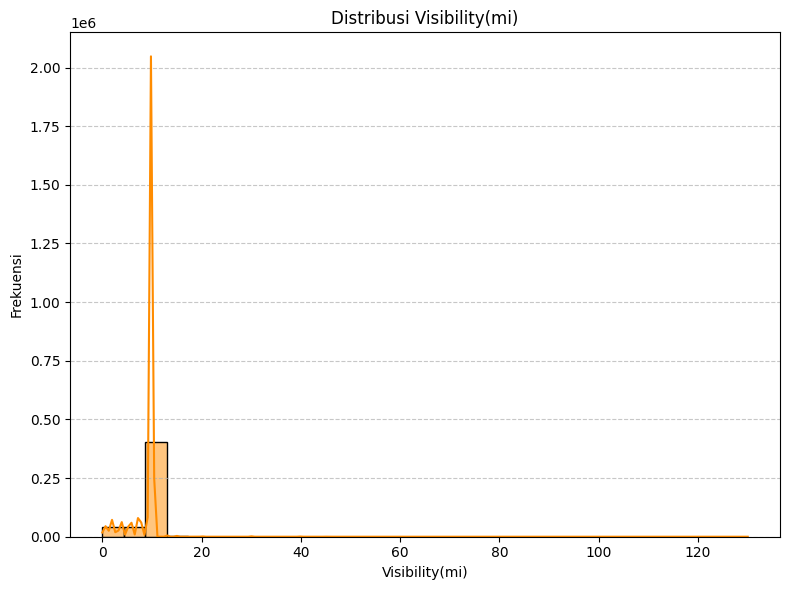

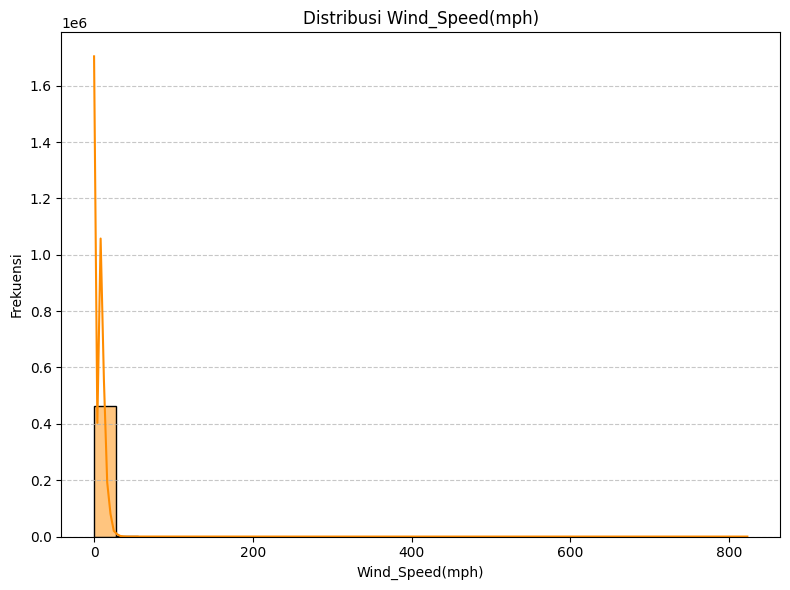

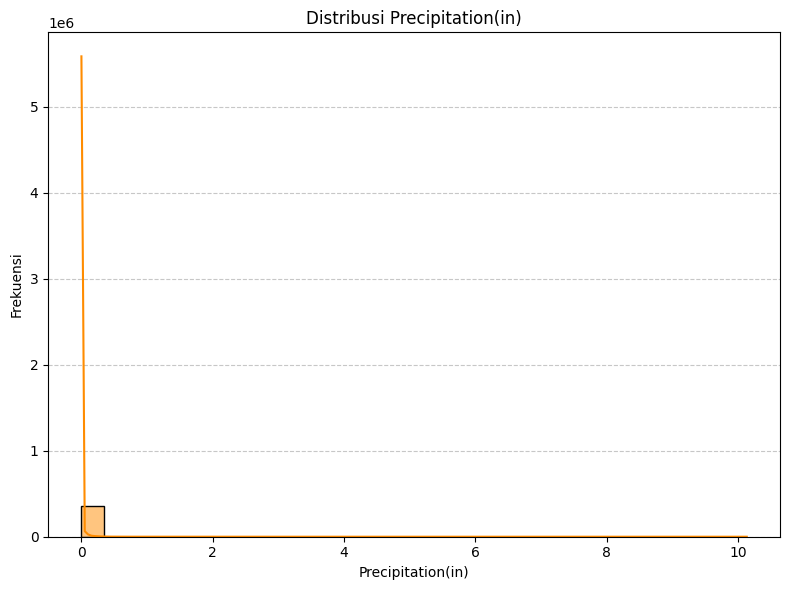

In [ ]:
for col in numerik:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col].dropna(), bins=30, kde=True, color='darkorange') # Using a darker orange for consistency
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

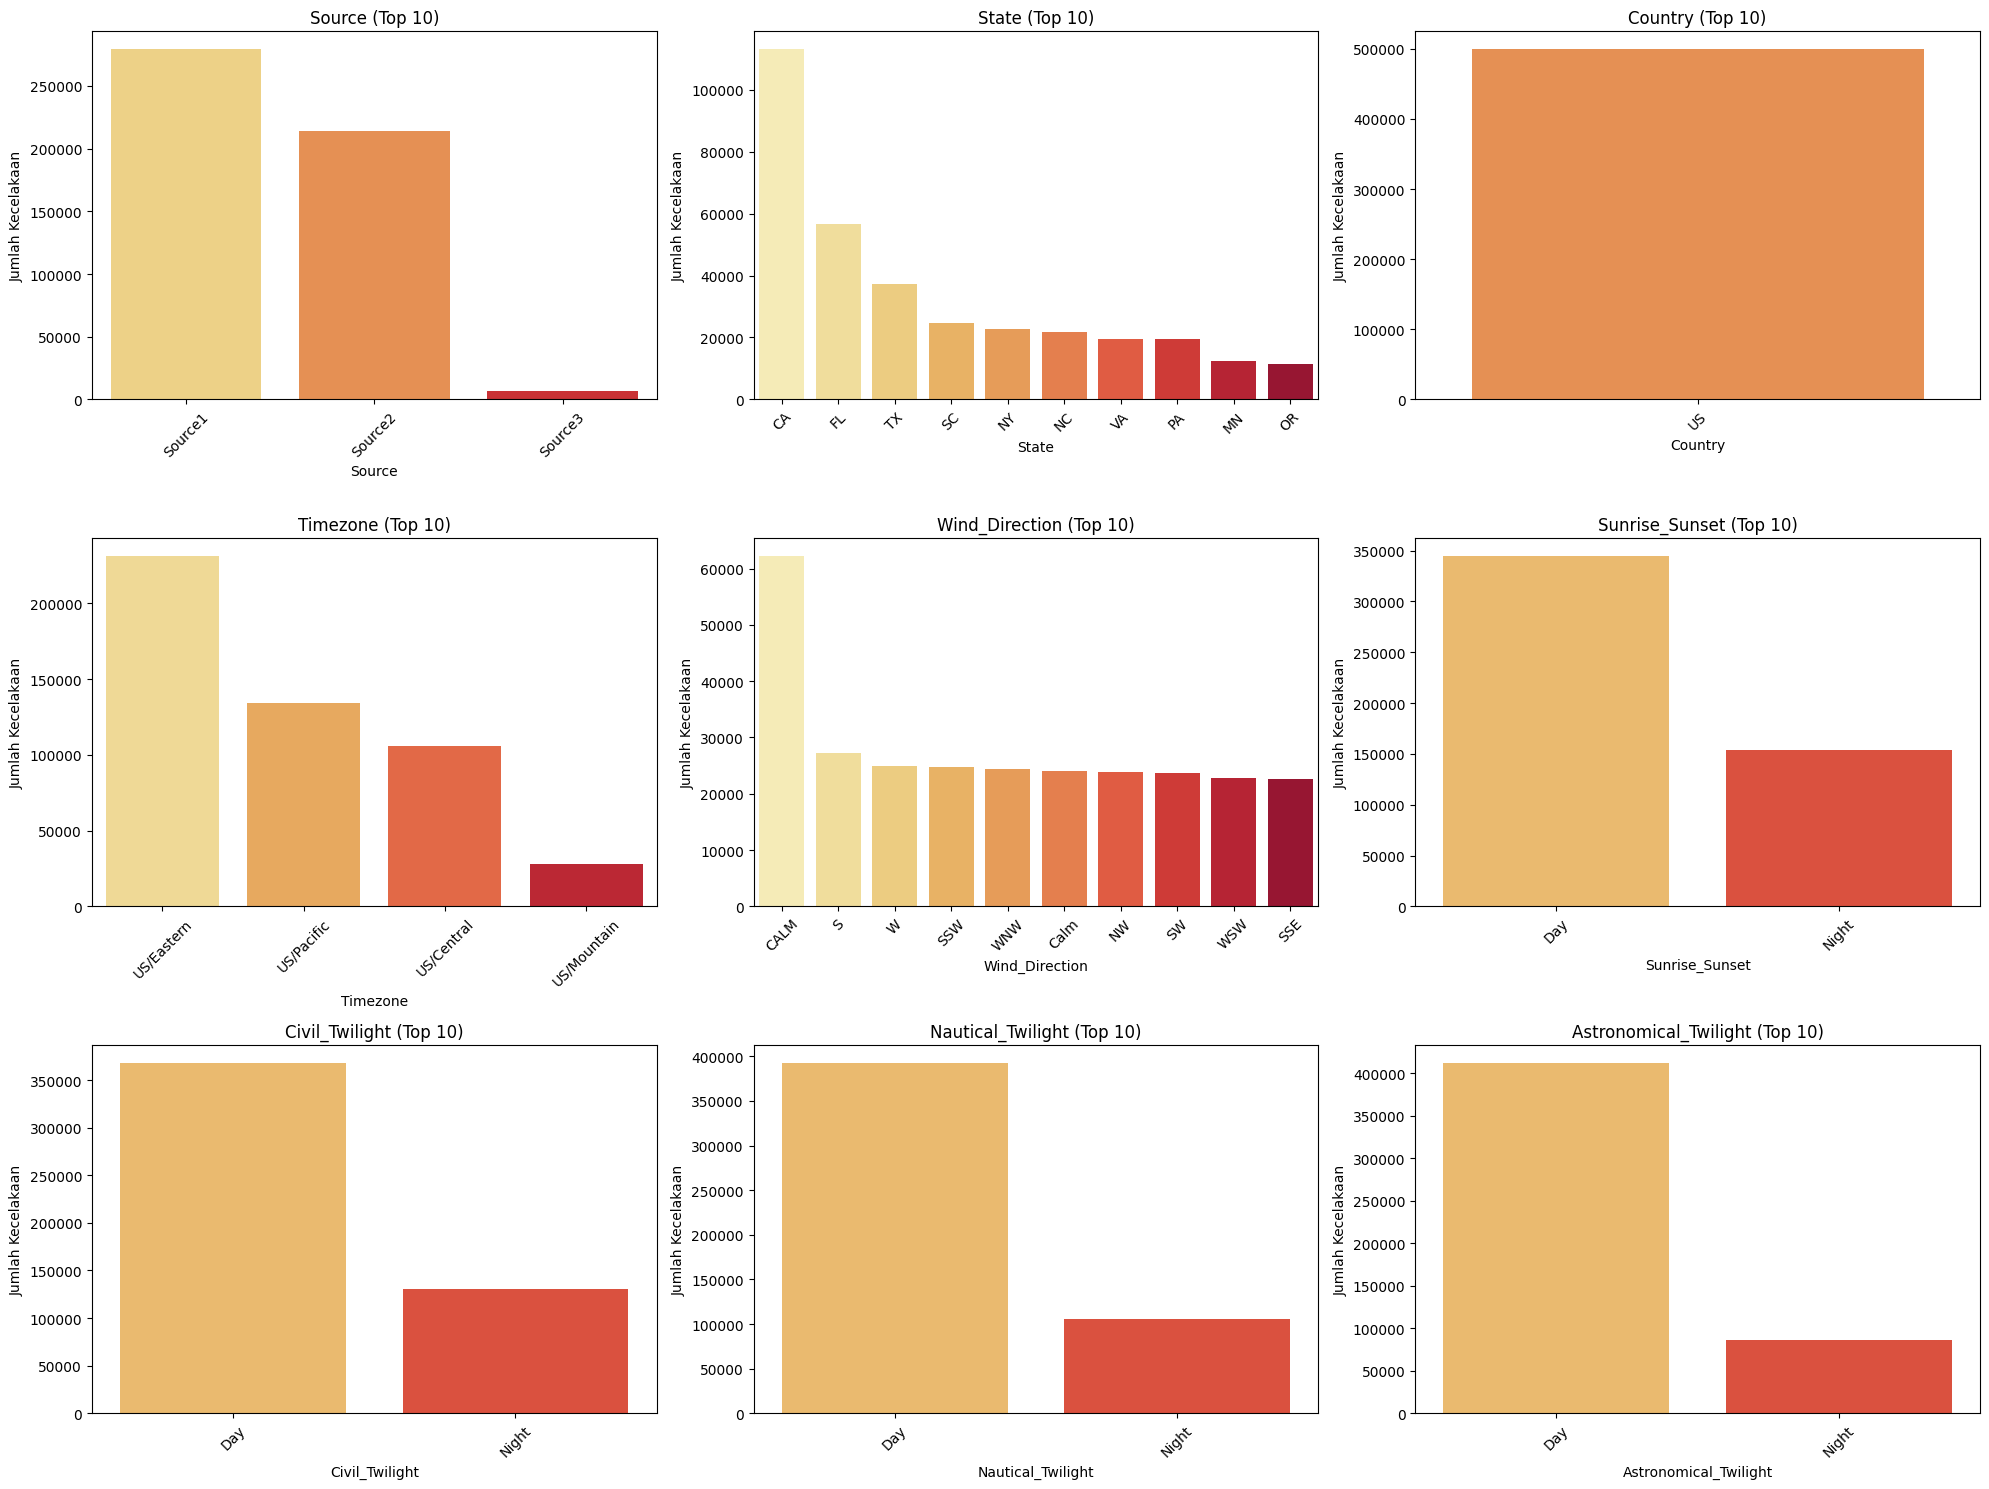

In [ ]:
kolom_plot = [col for col in kategorikal if df[col].nunique() <= 50]

n_cols = 3
n_rows = math.ceil(len(kolom_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(kolom_plot):
    # Calculate value counts to get counts for each category
    top_categories_counts = df[col].value_counts().nlargest(10) # This is now a Series

    # Use barplot to allow direct mapping of values to palette intensity
    sns.barplot(
        x=top_categories_counts.index,
        y=top_categories_counts.values,
        ax=axes[i],
        palette='YlOrRd' # Use a sequential palette
    )

    axes[i].set_title(f'{col} (Top 10)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Jumlah Kecelakaan')

for j in range(len(kolom_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

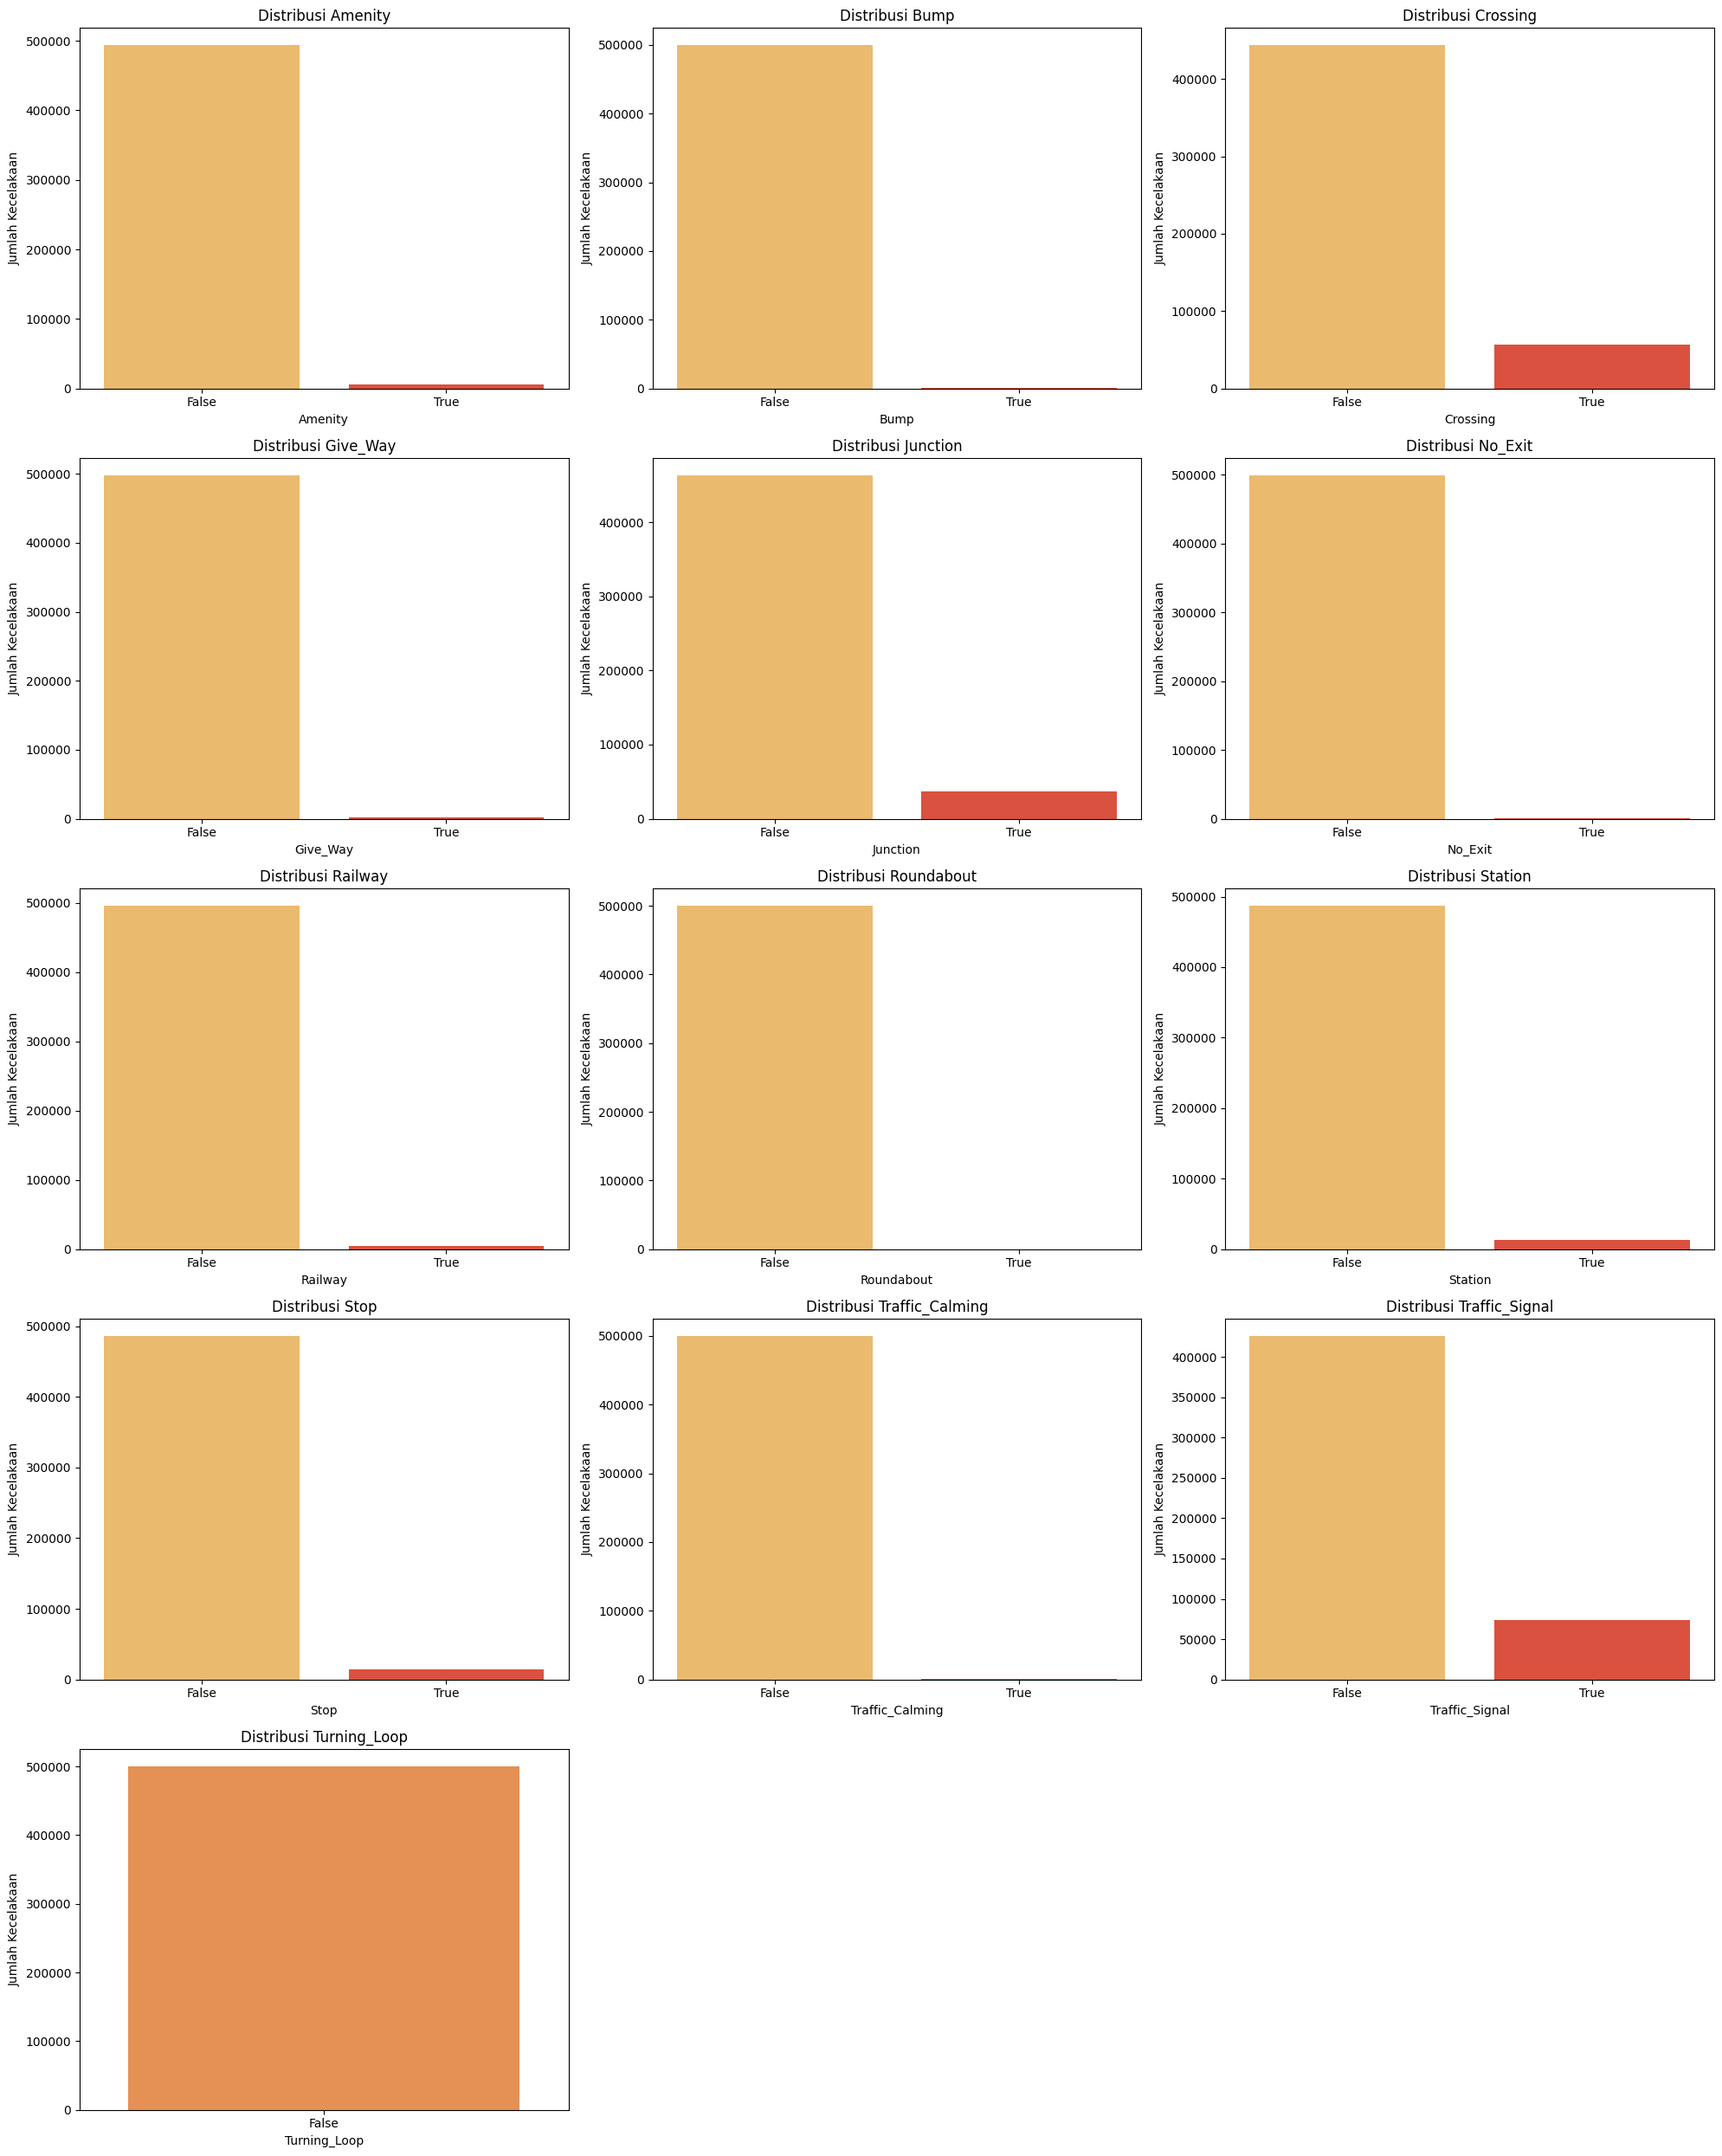

In [ ]:
n_cols_bool = 3
n_rows_bool = math.ceil(len(boolean) / n_cols_bool)

fig_bool, axes_bool = plt.subplots(n_rows_bool, n_cols_bool, figsize=(20, 5 * n_rows_bool))
axes_bool = axes_bool.flatten()

for i, col in enumerate(boolean):
    # Calculate value counts
    counts = df[col].value_counts().sort_values(ascending=False)
    counts_df = counts.reset_index()
    counts_df.columns = [col, 'Count']

    sns.barplot(
        data=counts_df,
        x=col,
        y='Count',
        ax=axes_bool[i],
        palette='YlOrRd' # Use a sequential palette
    )
    axes_bool[i].set_title(f'Distribusi {col}')
    axes_bool[i].set_xlabel(col)
    axes_bool[i].set_ylabel('Jumlah Kecelakaan')

for j in range(len(boolean), len(axes_bool)):
    axes_bool[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
display(df.describe())

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,279623.000000,279623.000000,500000.000000,489534.000000,370983.000000,488870.000000,491072.000000,488709.000000,463013.000000,357384.000000
mean,2.212748,36.206421,-94.736583,36.273192,-95.776553,0.564317,61.646254,58.229028,64.834921,29.536621,9.091540,7.681347,0.008289
std,0.486661,5.071411,17.405761,5.265333,18.120211,1.774872,19.000133,22.352246,22.826158,1.008666,2.708083,5.431361,0.101865
min,1.000000,24.562117,-124.497420,24.570110,-124.497419,0.000000,-77.800000,-53.200000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.416823,-117.233047,33.474773,-117.778324,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.832147,-87.794365,36.192669,-88.039013,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.082443,-80.359601,40.181341,-80.252449,0.465000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.999569,-67.484130,48.998901,-67.484130,193.479996,207.000000,207.000000,100.000000,38.440000,130.000000,822.800000,10.130000


# Missing Value

In [ ]:
missing_count = df.isnull().sum().sort_values(ascending=False)
display(missing_count[missing_count > 0])

,0
End_Lng,220377
End_Lat,220377
Precipitation(in),142616
Wind_Chill(F),129017
Wind_Speed(mph),36987
Visibility(mi),11291
Wind_Direction,11197
Humidity(%),11130
Weather_Condition,11101
Temperature(F),10466


# Handling Missing Values

In [ ]:
missing_coords_mask = df['End_Lat'].isnull() | df['End_Lng'].isnull()
sample_missing_rows_indices = df[missing_coords_mask].head(10).index

print("Data Sebelum Imputasi (sampel 10 baris dengan missing End_Lat/End_Lng):")
display(df.loc[sample_missing_rows_indices, ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng']])

df_final_imputed = df.copy()
df_final_imputed['End_Lat'].fillna(df_final_imputed['Start_Lat'], inplace=True)
df_final_imputed['End_Lng'].fillna(df_final_imputed['Start_Lng'], inplace=True)

print("\nData Sesudah Imputasi (kolom End_Lat/End_Lng diisi dari Start_Lat/Start_Lng):")
display(df_final_imputed.loc[sample_missing_rows_indices, ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng']])

Data Sebelum Imputasi (sampel 10 baris dengan missing End_Lat/End_Lng):


,Start_Lat,Start_Lng,End_Lat,End_Lng
0,30.641211,-91.153481,NaN,NaN
5,42.532082,-70.944267,NaN,NaN
10,39.933460,-86.157433,NaN,NaN
12,34.720150,-86.616592,NaN,NaN
14,33.436073,-111.926163,NaN,NaN
17,29.752390,-95.364708,NaN,NaN
18,41.926895,-73.912605,NaN,NaN
20,35.753944,-78.635696,NaN,NaN
21,34.243271,-118.424461,NaN,NaN
22,34.651295,-86.816582,NaN,NaN



Data Sesudah Imputasi (kolom End_Lat/End_Lng diisi dari Start_Lat/Start_Lng):


,Start_Lat,Start_Lng,End_Lat,End_Lng
0,30.641211,-91.153481,30.641211,-91.153481
5,42.532082,-70.944267,42.532082,-70.944267
10,39.933460,-86.157433,39.933460,-86.157433
12,34.720150,-86.616592,34.720150,-86.616592
14,33.436073,-111.926163,33.436073,-111.926163
17,29.752390,-95.364708,29.752390,-95.364708
18,41.926895,-73.912605,41.926895,-73.912605
20,35.753944,-78.635696,35.753944,-78.635696
21,34.243271,-118.424461,34.243271,-118.424461
22,34.651295,-86.816582,34.651295,-86.816582


In [ ]:
missing_precip_mask = df_final_imputed['Precipitation(in)'].isnull()
sample_missing_precip_rows_indices = df_final_imputed[missing_precip_mask].head(10).index

print("Data Sebelum Imputasi (sampel 10 baris dengan missing Precipitation(in)):")
display(df_final_imputed.loc[sample_missing_precip_rows_indices, ['Precipitation(in)']])

df_final_imputed['Precipitation(in)'].fillna(0, inplace=True)

print("\nData Sesudah Imputasi (kolom Precipitation(in) diisi dengan 0):")
display(df_final_imputed.loc[sample_missing_precip_rows_indices, ['Precipitation(in)']])

Data Sebelum Imputasi (sampel 10 baris dengan missing Precipitation(in)):


,Precipitation(in)
17,NaN
18,NaN
20,NaN
21,NaN
28,NaN
29,NaN
31,NaN
34,NaN
41,NaN
44,NaN



Data Sesudah Imputasi (kolom Precipitation(in) diisi dengan 0):


,Precipitation(in)
17,0.0
18,0.0
20,0.0
21,0.0
28,0.0
29,0.0
31,0.0
34,0.0
41,0.0
44,0.0


In [ ]:
numerical_cols_to_impute = [
    'Wind_Chill(F)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)'
]

sample_cols = ['Wind_Chill(F)','Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']

print("Data Sebelum Imputasi (sampel 10 baris dengan missing values di kolom numerik):")
missing_any_numeric_mask = df_final_imputed[numerical_cols_to_impute].isnull().any(axis=1)
sample_indices = df_final_imputed[missing_any_numeric_mask].head(10).index

display(df_final_imputed.loc[sample_indices, sample_cols])

for col in numerical_cols_to_impute:
    median_value = df_final_imputed[col].median()
    df_final_imputed[col].fillna(median_value, inplace=True)

print("\nData Sesudah Imputasi (kolom numerik diisi dengan median):")
display(df_final_imputed.loc[sample_indices, sample_cols])

Data Sebelum Imputasi (sampel 10 baris dengan missing values di kolom numerik):


,Wind_Chill(F),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
17,NaN,64.4,94.0,29.98,9.0,4.6
18,NaN,84.0,55.0,29.75,10.0,5.8
28,NaN,76.8,40.0,29.97,10.0,3.5
29,NaN,55.9,67.0,30.17,10.0,6.9
31,NaN,62.6,59.0,29.99,10.0,5.8
34,NaN,68.7,22.0,30.26,10.0,5.8
36,70.0,70.0,55.0,29.51,NaN,12.0
41,NaN,72.0,91.0,29.36,10.0,NaN
44,NaN,91.9,41.0,29.89,10.0,11.5
46,NaN,73.0,93.0,30.04,6.0,NaN



Data Sesudah Imputasi (kolom numerik diisi dengan median):


,Wind_Chill(F),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
17,62.0,64.4,94.0,29.98,9.0,4.6
18,62.0,84.0,55.0,29.75,10.0,5.8
28,62.0,76.8,40.0,29.97,10.0,3.5
29,62.0,55.9,67.0,30.17,10.0,6.9
31,62.0,62.6,59.0,29.99,10.0,5.8
34,62.0,68.7,22.0,30.26,10.0,5.8
36,70.0,70.0,55.0,29.51,10.0,12.0
41,62.0,72.0,91.0,29.36,10.0,7.0
44,62.0,91.9,41.0,29.89,10.0,11.5
46,62.0,73.0,93.0,30.04,6.0,7.0


In [ ]:
categorical_cols_to_impute = [
    'Street', 'City', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp',
    'Weather_Condition', 'Wind_Direction', 'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight', 'Description'
]


sample_cat_cols = ['Street', 'Weather_Condition', 'Wind_Direction']

print("Data Sebelum Imputasi (sampel 10 baris dengan missing values di kolom kategorikal):")
missing_any_categorical_mask = df_final_imputed[categorical_cols_to_impute].isnull().any(axis=1)
sample_indices_cat = df_final_imputed[missing_any_categorical_mask].head(10).index

display(df_final_imputed.loc[sample_indices_cat, sample_cat_cols])

for col in categorical_cols_to_impute:
    df_final_imputed[col].fillna('Unknown', inplace=True)

print("\nData Sesudah Imputasi (kolom kategorikal diisi dengan 'Unknown')):")
display(df_final_imputed.loc[sample_indices_cat, sample_cat_cols])

Data Sebelum Imputasi (sampel 10 baris dengan missing values di kolom kategorikal):


,Street,Weather_Condition,Wind_Direction
83,Golden State Fwy N,Fair,NaN
89,W 600 S,NaN,NaN
90,Trona Wildrose Rd,NaN,NaN
179,E 5th St,Fair,NaN
222,Patapsco Fwy,NaN,North
297,I-695 W,NaN,NaN
300,I-95 S,NaN,North
322,I-635 S,NaN,North
350,Evergreen Ave,Mostly Cloudy,NaN
406,I-10,Partly Cloudy,NaN



Data Sesudah Imputasi (kolom kategorikal diisi dengan 'Unknown')):


,Street,Weather_Condition,Wind_Direction
83,Golden State Fwy N,Fair,Unknown
89,W 600 S,Unknown,Unknown
90,Trona Wildrose Rd,Unknown,Unknown
179,E 5th St,Fair,Unknown
222,Patapsco Fwy,Unknown,North
297,I-695 W,Unknown,Unknown
300,I-95 S,Unknown,North
322,I-635 S,Unknown,North
350,Evergreen Ave,Mostly Cloudy,Unknown
406,I-10,Partly Cloudy,Unknown


In [ ]:
print("\nMissing values setelah semua imputasi pada df_final_imputed:")
missing_count_final = df_final_imputed.isnull().sum().sort_values(ascending=False)
display(missing_count_final)

if missing_count_final[missing_count_final > 0].empty:
    print("Semua missing values telah berhasil ditangani!")
else:
    print("Masih ada missing values yang tersisa seperti di atas.")


Missing values setelah semua imputasi pada df_final_imputed:


,0
ID,0
Source,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
End_Lat,0
End_Lng,0
Distance(mi),0


Semua missing values telah berhasil ditangani!


## Deteksi Outlier pada Numerikal

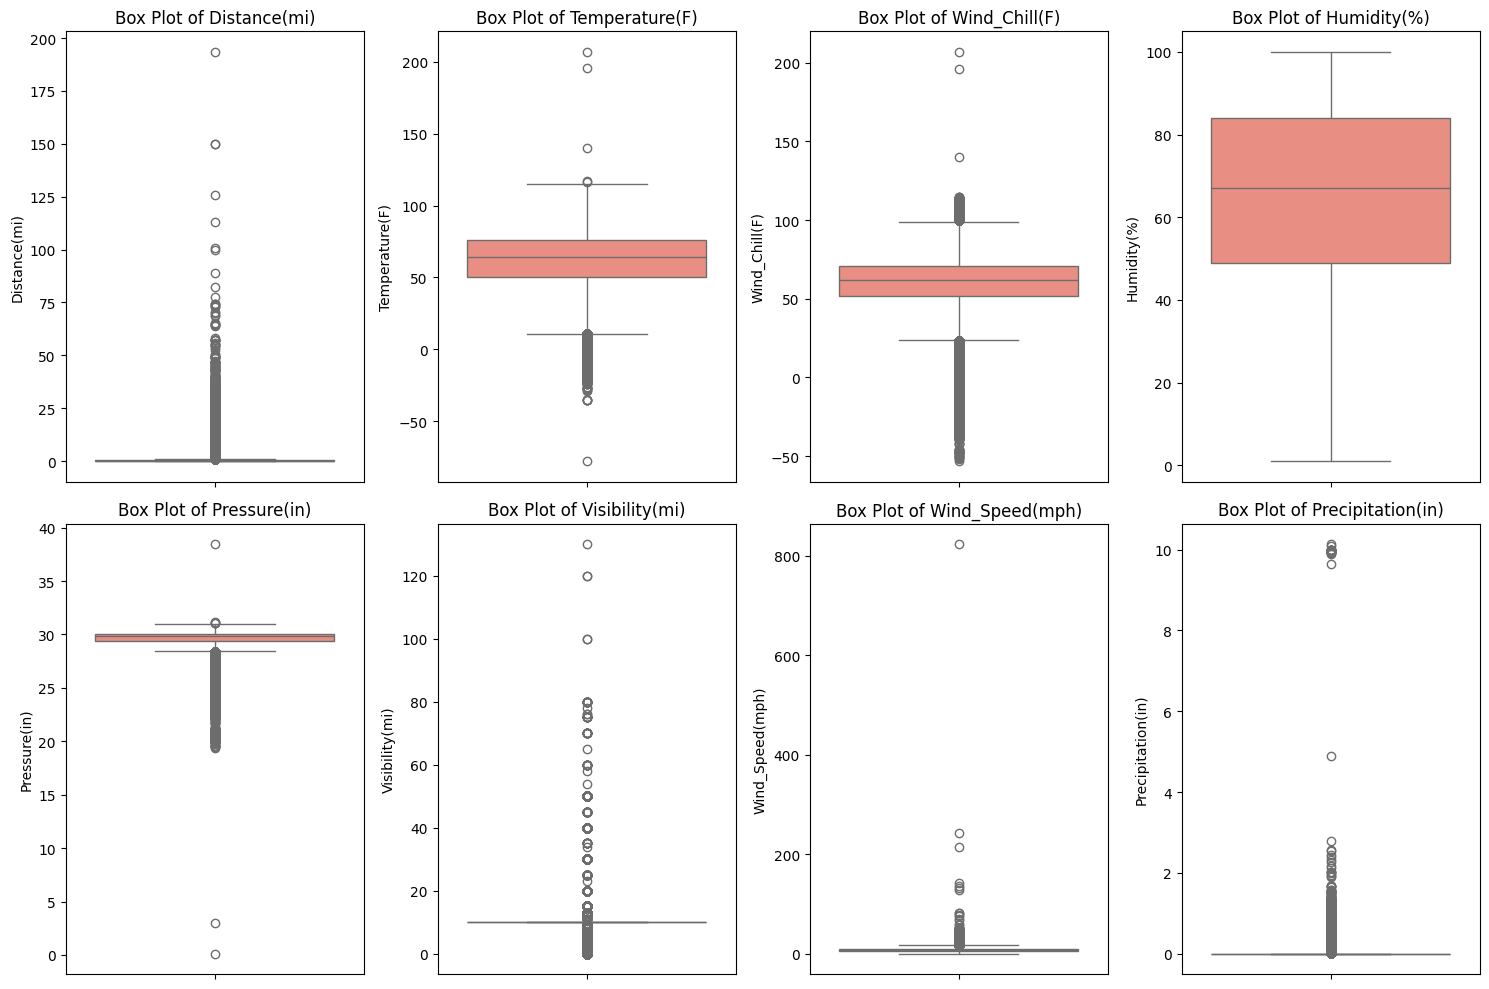

In [ ]:
numerical_features_for_outliers = [
    'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features_for_outliers, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_final_imputed[feature], color='salmon')
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

Statistik Fitur Numerik SEBELUM Capping:


,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,0.564317,61.695523,59.202067,64.883116,29.542395,9.112055,7.630945,0.005925
std,1.774872,18.803245,19.324219,22.572933,1.000537,2.680731,5.229653,0.086202
min,0.000000,-77.800000,-53.200000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,0.000000,50.000000,52.000000,49.000000,29.380000,10.000000,5.000000,0.000000
50%,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,0.465000,76.000000,71.000000,84.000000,30.030000,10.000000,10.000000,0.000000
max,193.479996,207.000000,207.000000,100.000000,38.440000,130.000000,822.800000,10.130000



Statistik Fitur Numerik SETELAH Capping:


,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,0.408396,61.945711,59.600692,65.130818,29.643490,9.118808,7.457922,0.000689
std,0.726570,17.367608,17.267676,21.637292,0.565353,2.102586,4.604894,0.002532
min,0.000000,28.000000,22.000000,24.000000,28.030000,2.500000,0.000000,0.000000
25%,0.000000,50.000000,52.000000,49.000000,29.380000,10.000000,5.000000,0.000000
50%,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,0.465000,76.000000,71.000000,84.000000,30.030000,10.000000,10.000000,0.000000
max,2.684000,89.000000,87.000000,97.000000,30.250000,10.000000,17.000000,0.010000


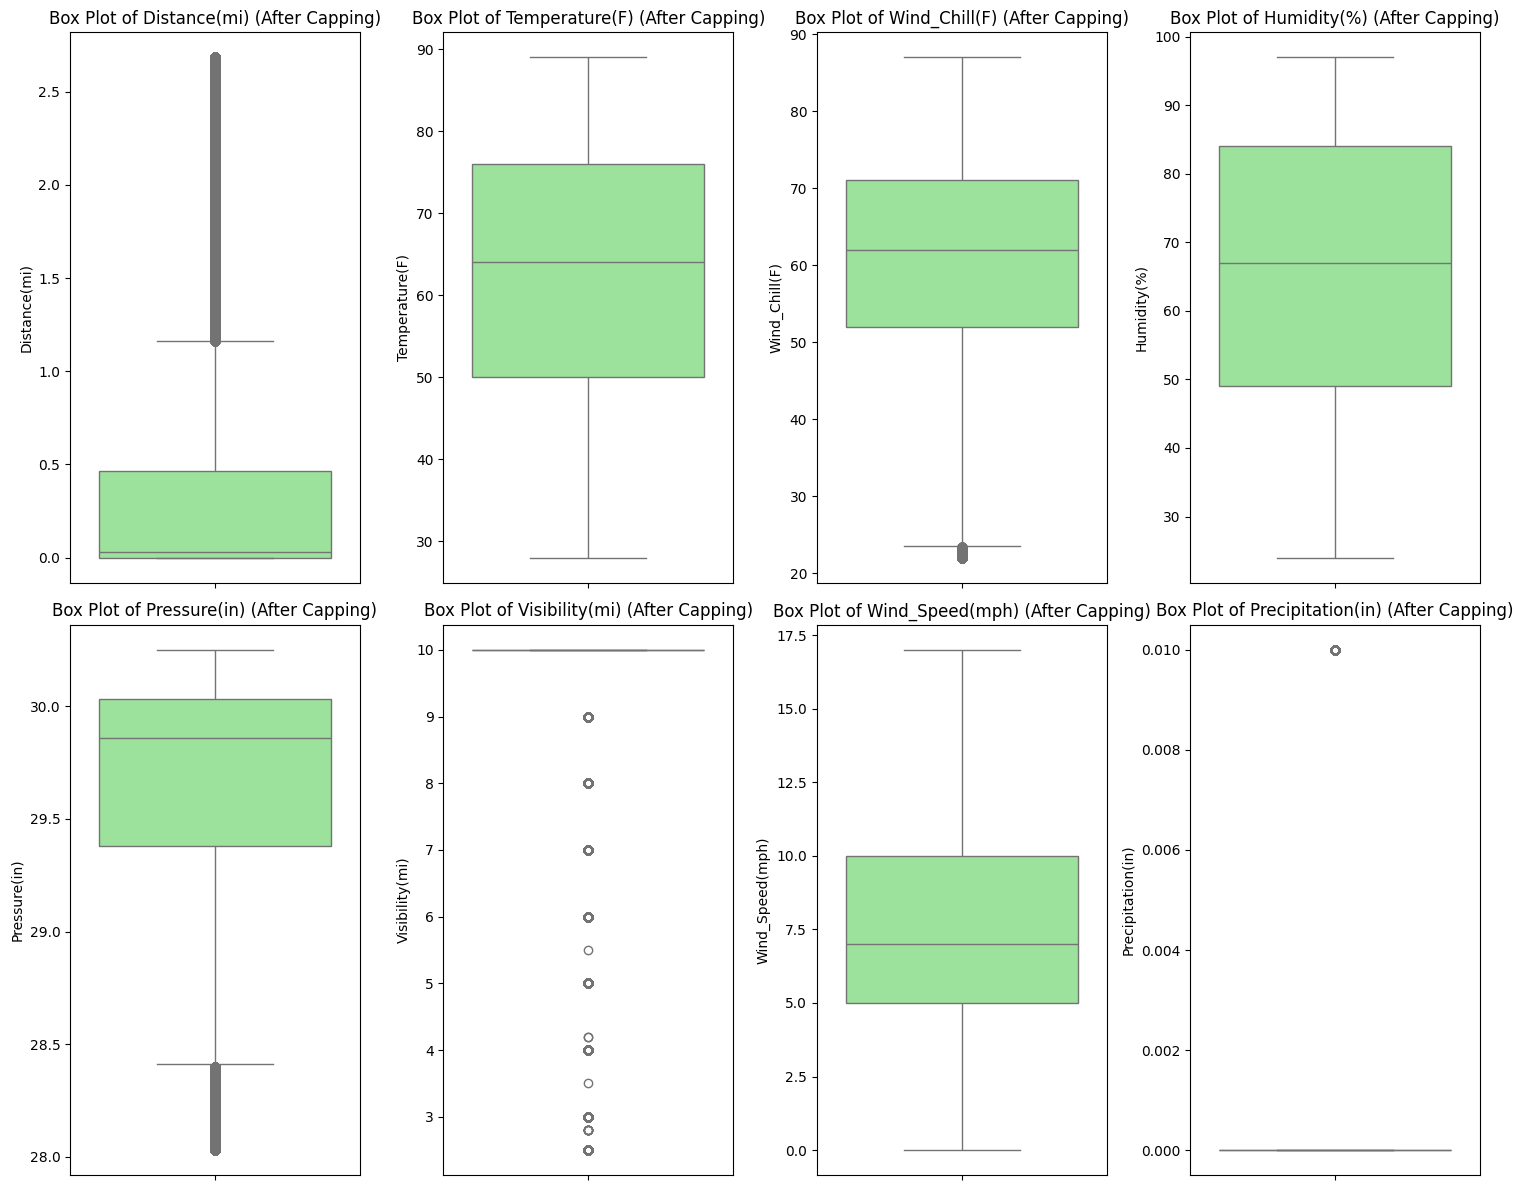

In [ ]:
features_to_cap = ['Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

df_capped = df_final_imputed.copy()

print("Statistik Fitur Numerik SEBELUM Capping:")
display(df_capped[features_to_cap].describe())

for feature in features_to_cap:
    lower_bound = df_capped[feature].quantile(0.05) # Batas bawah persentil ke-5
    upper_bound = df_capped[feature].quantile(0.95) # Batas atas persentil ke-95

    df_capped[feature] = np.where(df_capped[feature] < lower_bound, lower_bound, df_capped[feature])
    df_capped[feature] = np.where(df_capped[feature] > upper_bound, upper_bound, df_capped[feature])

print("\nStatistik Fitur Numerik SETELAH Capping:")
display(df_capped[features_to_cap].describe())

plt.figure(figsize=(15, 12))
for i, feature in enumerate(features_to_cap, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_capped[feature], color='lightgreen')
    plt.title(f'Box Plot of {feature} (After Capping)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Deteksi Outlier pada Fitur Kategorikal



Distribusi frekuensi untuk Street:


,proportion
Street,
I-95 N,0.009946
I-95 S,0.009732
I-5 N,0.009104
I-10 E,0.007166
I-10 W,0.006968
I-5 S,0.006710
I-80 W,0.005076
I-80 E,0.004730
I-405 N,0.004096


Jumlah kategori unik: 88273


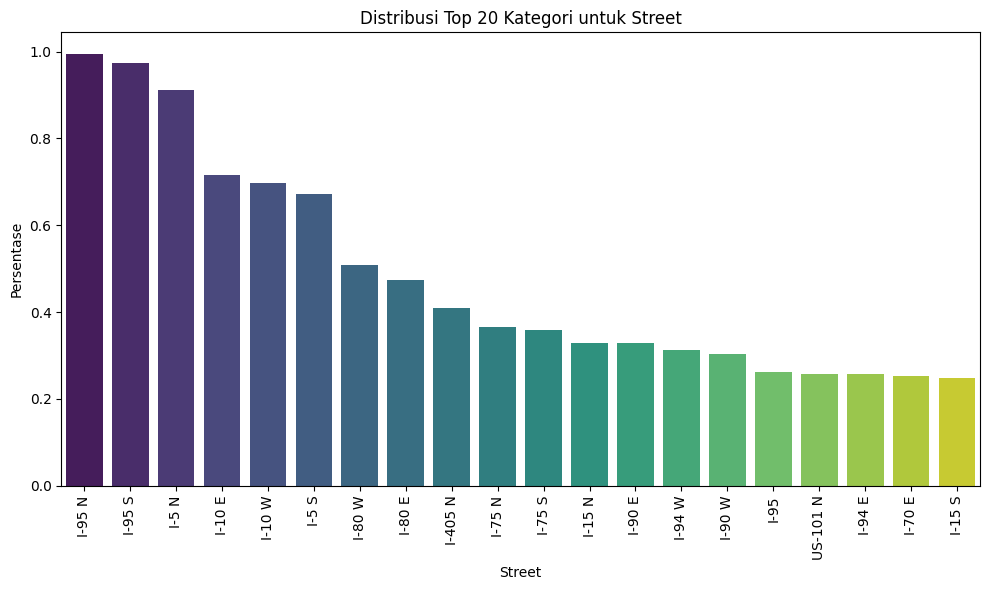

Tidak ada kategori dengan frekuensi sangat rendah di Street.

Distribusi frekuensi untuk City:


,proportion
City,
Miami,0.024282
Houston,0.022062
Los Angeles,0.020598
Charlotte,0.017958
Dallas,0.016490
Orlando,0.013970
Austin,0.012538
Raleigh,0.011106
Nashville,0.009378


Jumlah kategori unik: 9489


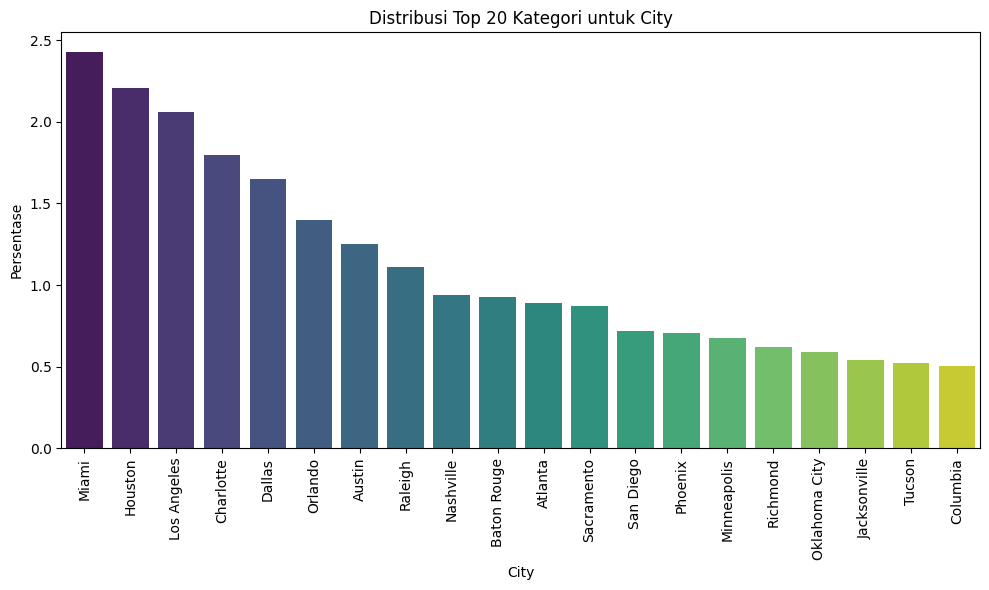

Tidak ada kategori dengan frekuensi sangat rendah di City.

Distribusi frekuensi untuk Zipcode:


,proportion
Zipcode,
91761,0.001440
91706,0.001288
92407,0.001174
92507,0.001126
33186,0.001062
33169,0.001008
32819,0.000994
92324,0.000954
90023,0.000922


Jumlah kategori unik: 127805


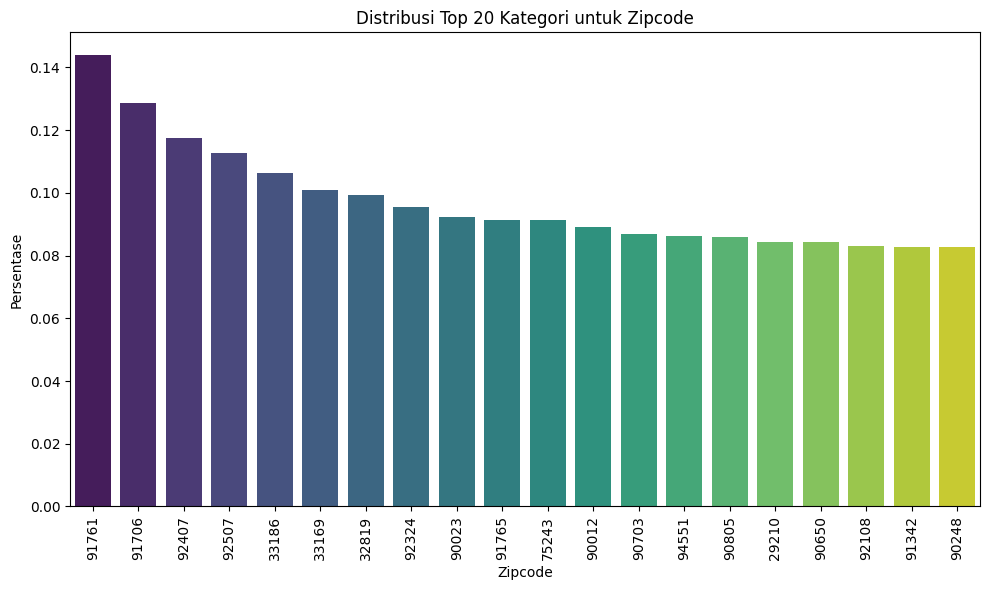

Tidak ada kategori dengan frekuensi sangat rendah di Zipcode.

Distribusi frekuensi untuk Timezone:


,proportion
Timezone,
US/Eastern,0.462794
US/Pacific,0.267974
US/Central,0.212024
US/Mountain,0.056194
Unknown,0.001014


Jumlah kategori unik: 5


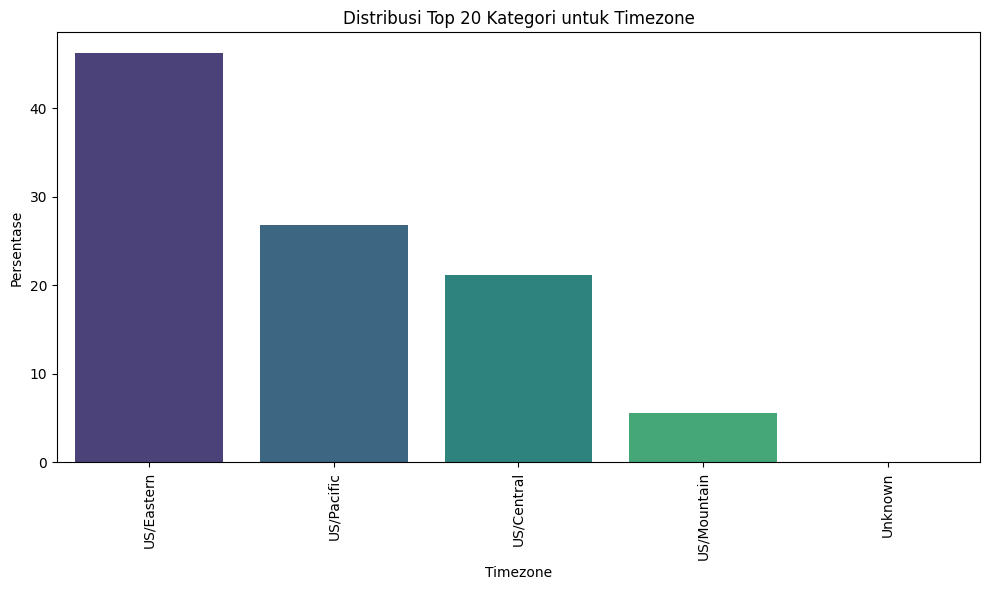

Tidak ada kategori dengan frekuensi sangat rendah di Timezone.

Distribusi frekuensi untuk Airport_Code:


,proportion
Airport_Code,
KCQT,0.015512
KRDU,0.013690
KMCJ,0.013148
KBNA,0.012856
KCLT,0.012662
KMIA,0.010598
KORL,0.010274
KBTR,0.010140
KOPF,0.009126


Jumlah kategori unik: 1879


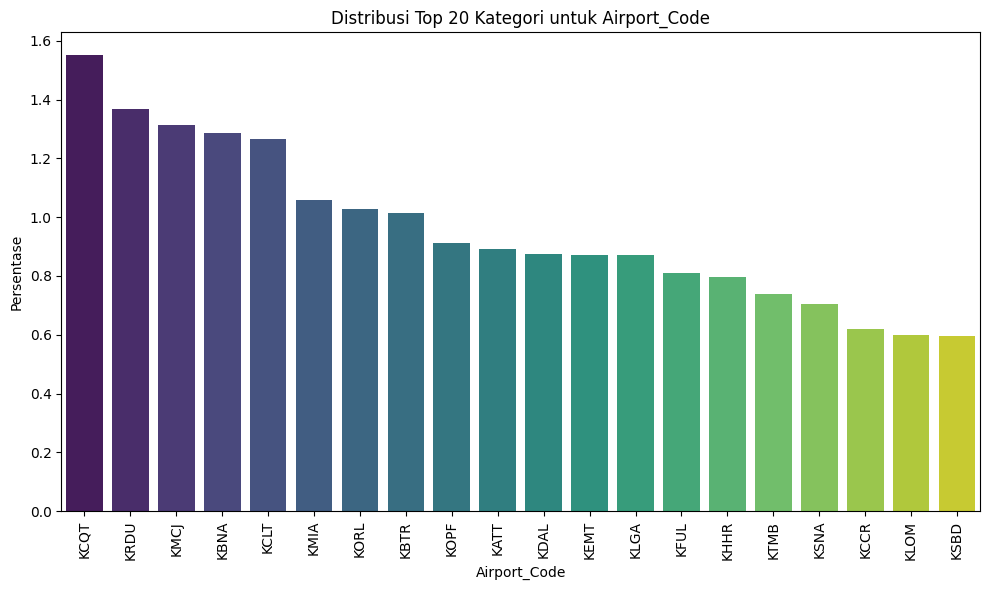

Tidak ada kategori dengan frekuensi sangat rendah di Airport_Code.

Distribusi frekuensi untuk Weather_Timestamp:


,proportion
Weather_Timestamp,
Unknown,0.015348
2022-03-13 01:53:00,0.000184
2021-01-26 15:53:00,0.000096
2021-12-03 16:53:00,0.000080
2022-04-13 16:53:00,0.000080
2021-01-15 22:53:00,0.000078
2022-04-08 15:53:00,0.000076
2022-05-13 15:53:00,0.000074
2022-03-13 01:55:00,0.000072


Jumlah kategori unik: 255624


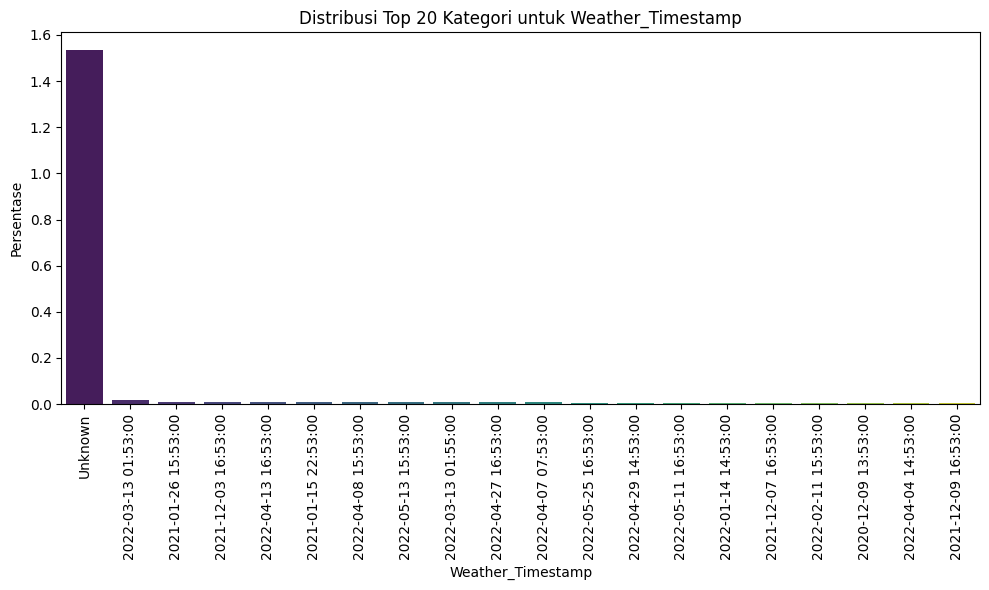

Kategori dengan frekuensi sangat rendah (<0.01%) di Weather_Timestamp: ['2021-01-26 15:53:00', '2021-12-03 16:53:00', '2022-04-13 16:53:00', '2021-01-15 22:53:00', '2022-04-08 15:53:00', '2022-05-13 15:53:00', '2022-03-13 01:55:00', '2022-04-27 16:53:00', '2022-04-07 07:53:00', '2022-05-25 16:53:00', '2022-04-29 14:53:00', '2022-05-11 16:53:00', '2022-01-14 14:53:00', '2021-12-07 16:53:00', '2022-02-11 15:53:00', '2020-12-09 13:53:00', '2022-04-04 14:53:00', '2021-12-09 16:53:00']

Distribusi frekuensi untuk Weather_Condition:


,proportion
Weather_Condition,
Fair,0.332106
Mostly Cloudy,0.130796
Cloudy,0.106214
Clear,0.104758
Partly Cloudy,0.090250
Overcast,0.049802
Light Rain,0.045436
Scattered Clouds,0.026060
Unknown,0.022202


Jumlah kategori unik: 109


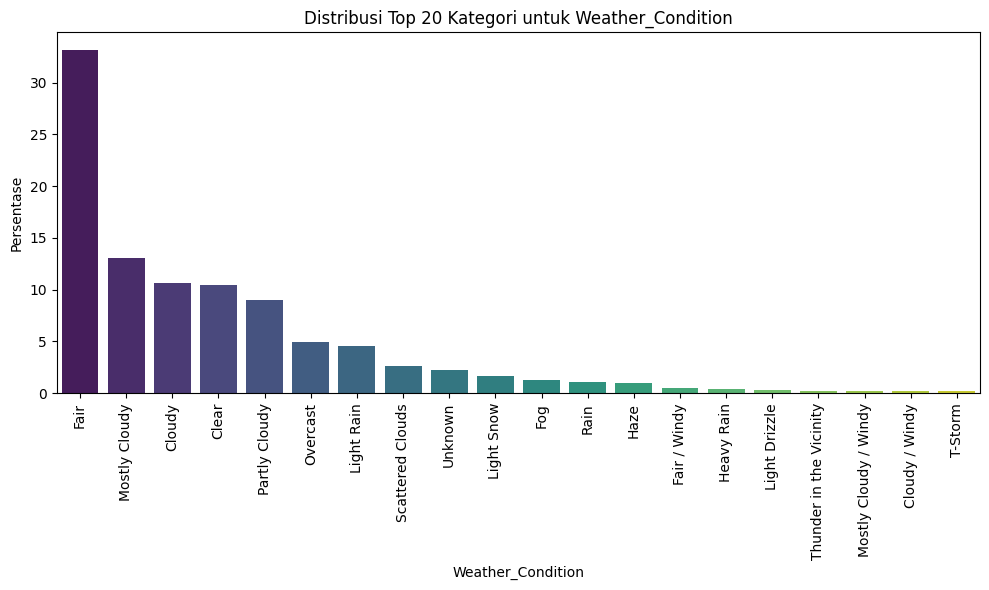

Tidak ada kategori dengan frekuensi sangat rendah di Weather_Condition.

Distribusi frekuensi untuk Wind_Direction:


,proportion
Wind_Direction,
CALM,0.124518
S,0.054364
W,0.049952
SSW,0.049610
WNW,0.048656
Calm,0.048044
NW,0.047778
SW,0.047296
WSW,0.045738


Jumlah kategori unik: 25


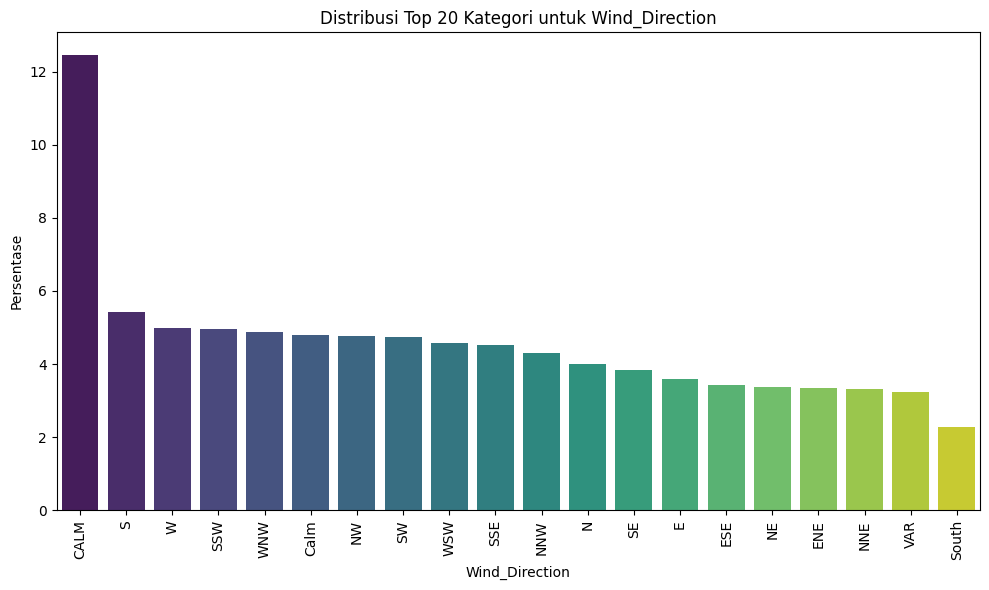

Tidak ada kategori dengan frekuensi sangat rendah di Wind_Direction.

Distribusi frekuensi untuk Sunrise_Sunset:


,proportion
Sunrise_Sunset,
Day,0.689934
Night,0.307100
Unknown,0.002966


Jumlah kategori unik: 3


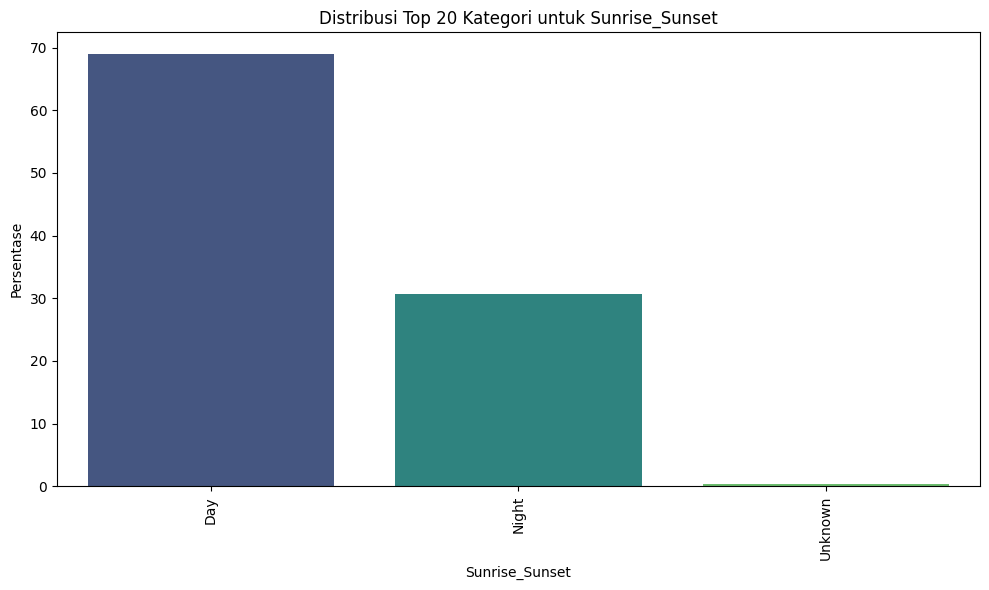

Tidak ada kategori dengan frekuensi sangat rendah di Sunrise_Sunset.

Distribusi frekuensi untuk Civil_Twilight:


,proportion
Civil_Twilight,
Day,0.736548
Night,0.260486
Unknown,0.002966


Jumlah kategori unik: 3


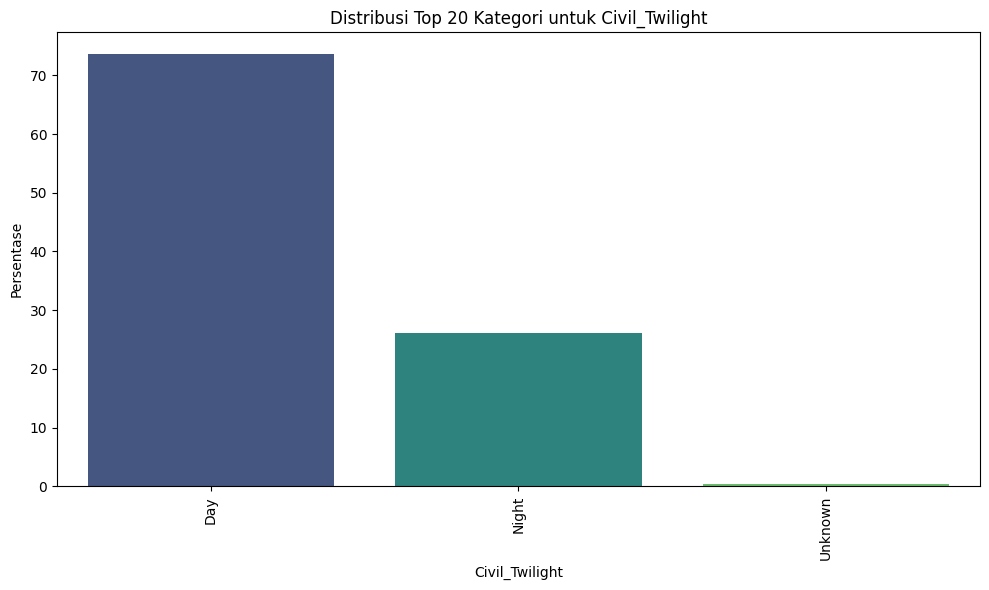

Tidak ada kategori dengan frekuensi sangat rendah di Civil_Twilight.

Distribusi frekuensi untuk Nautical_Twilight:


,proportion
Nautical_Twilight,
Day,0.785732
Night,0.211302
Unknown,0.002966


Jumlah kategori unik: 3


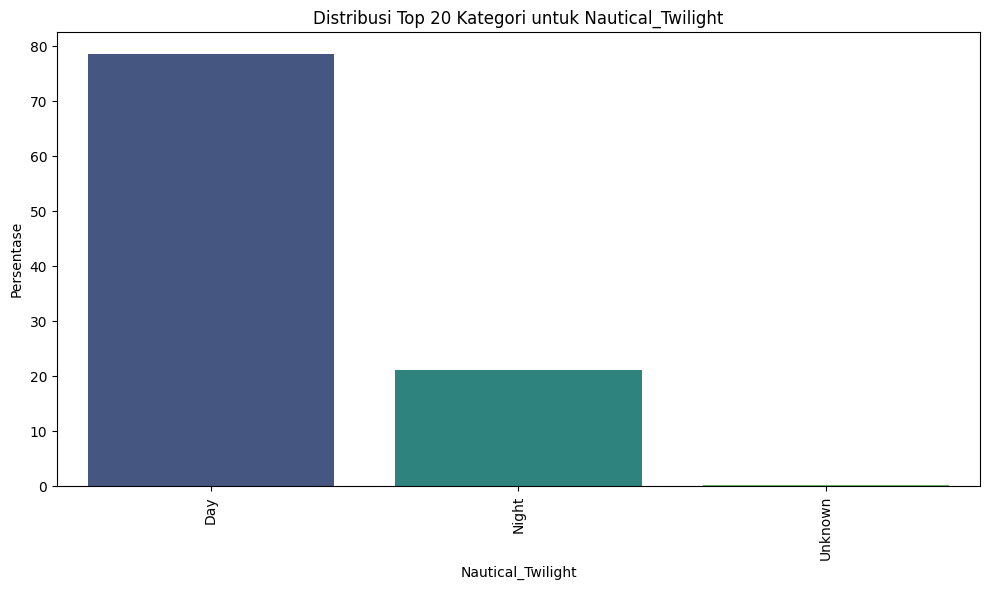

Tidak ada kategori dengan frekuensi sangat rendah di Nautical_Twilight.

Distribusi frekuensi untuk Astronomical_Twilight:


,proportion
Astronomical_Twilight,
Day,0.824484
Night,0.172550
Unknown,0.002966


Jumlah kategori unik: 3


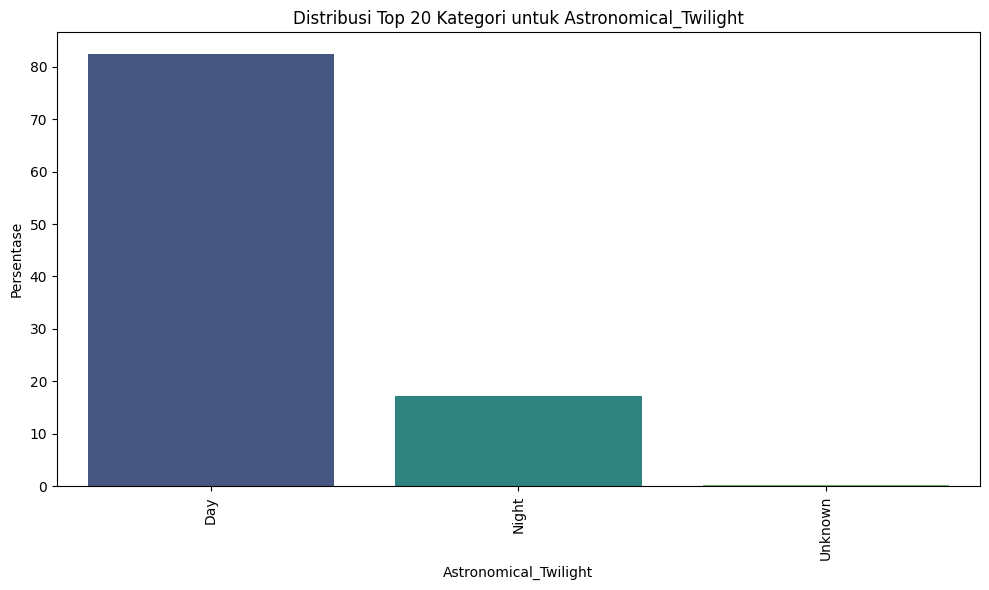

Tidak ada kategori dengan frekuensi sangat rendah di Astronomical_Twilight.

Distribusi frekuensi untuk Description:


,proportion
Description,
A crash has occurred causing no to minimum delays. Use caution.,0.001184
Accident,0.000838
An unconfirmed report of a crash has been received. Use caution.,0.000486
A crash has occurred with minimal delay to traffic. Prepare to slow or move over for worker safety.,0.000366
A crash has occurred use caution.,0.000362
A disabled vehicle is creating a hazard causing no to minimum delays. Use caution.,0.000294
At I-15 - Accident.,0.000272
At I-5 - Accident.,0.000256
Incident on I-95 SB near I-95 Drive with caution.,0.000240


Jumlah kategori unik: 408146


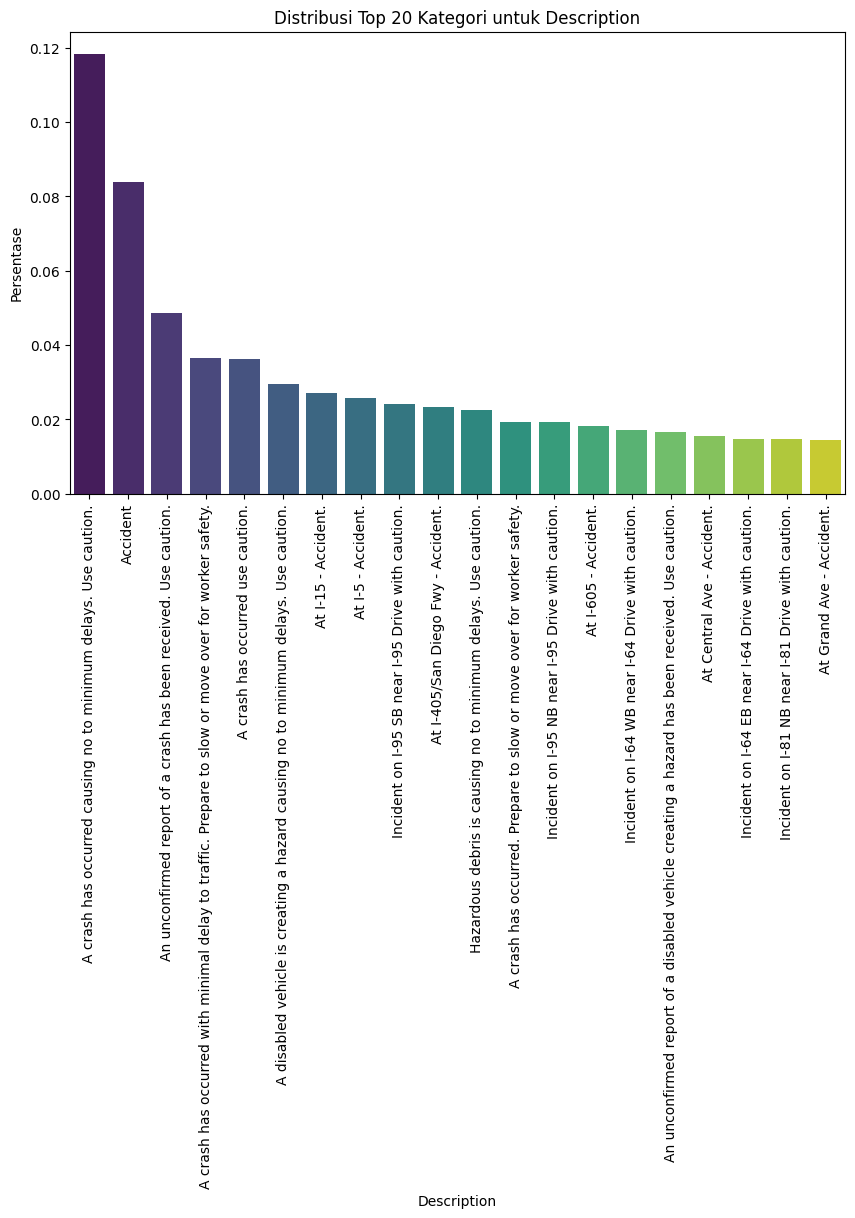

Tidak ada kategori dengan frekuensi sangat rendah di Description.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_for_outliers = [
    'Street', 'City', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp',
    'Weather_Condition', 'Wind_Direction', 'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight', 'Description'
]

for feature in categorical_features_for_outliers:
    print(f"\nDistribusi frekuensi untuk {feature}:")
    value_counts = df_final_imputed[feature].value_counts(normalize=True).head(20)
    display(value_counts)
    print(f"Jumlah kategori unik: {df_final_imputed[feature].nunique()}")

    # Plot top N categories, for example, top 10 for better visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(x=value_counts.index, y=value_counts.values * 100, palette='viridis')
    plt.title(f'Distribusi Top 20 Kategori untuk {feature}')
    plt.xlabel(feature)
    plt.ylabel('Persentase')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # Identify categories with very low frequency (e.g., less than 0.01%)
    low_frequency_categories = value_counts[value_counts < 0.0001].index.tolist()
    if low_frequency_categories:
        print(f"Kategori dengan frekuensi sangat rendah (<0.01%) di {feature}: {low_frequency_categories}")
    else:
        print(f"Tidak ada kategori dengan frekuensi sangat rendah di {feature}.")

### Deteksi Outlier pada Fitur Boolean




Deteksi Outlier pada Fitur Boolean (frekuensi rendah):

Distribusi untuk Amenity:


,proportion
Amenity,
False,0.987618
True,0.012382


  -> Tidak ada nilai dengan frekuensi sangat rendah di Amenity.


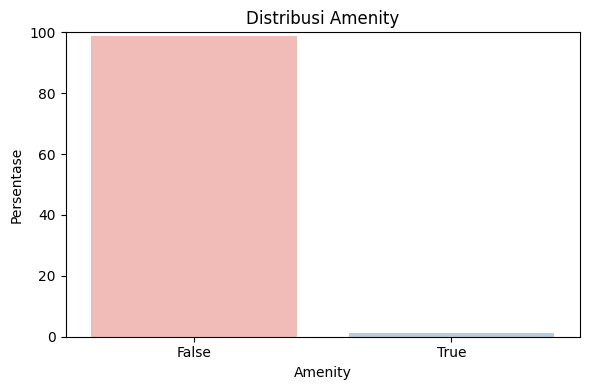


Distribusi untuk Bump:


,proportion
Bump,
False,0.999578
True,0.000422


  -> Tidak ada nilai dengan frekuensi sangat rendah di Bump.


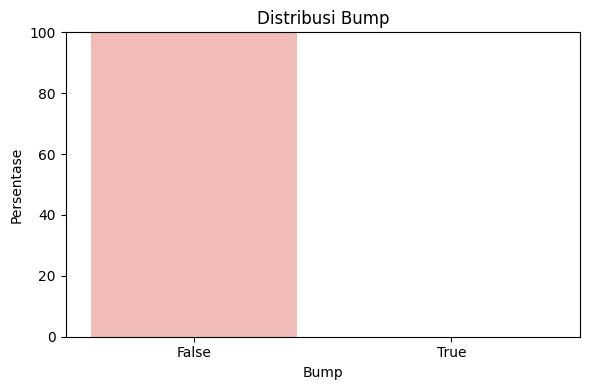


Distribusi untuk Crossing:


,proportion
Crossing,
False,0.887494
True,0.112506


  -> Tidak ada nilai dengan frekuensi sangat rendah di Crossing.


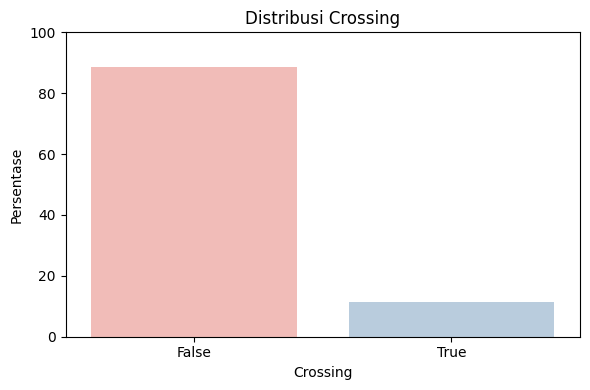


Distribusi untuk Give_Way:


,proportion
Give_Way,
False,0.995276
True,0.004724


  -> Tidak ada nilai dengan frekuensi sangat rendah di Give_Way.


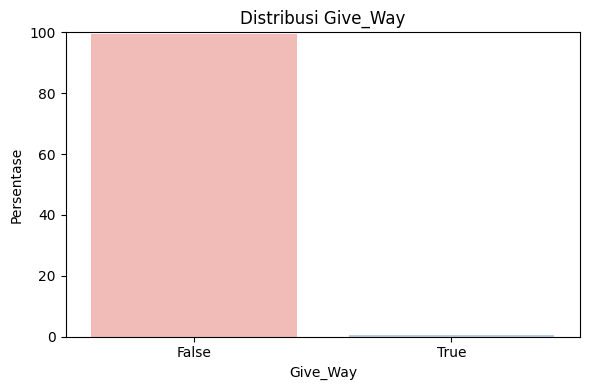


Distribusi untuk Junction:


,proportion
Junction,
False,0.925986
True,0.074014


  -> Tidak ada nilai dengan frekuensi sangat rendah di Junction.


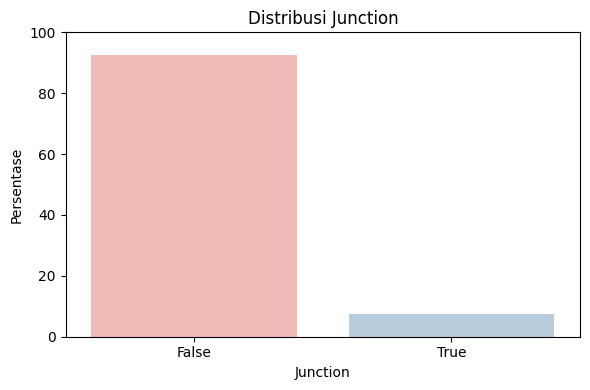


Distribusi untuk No_Exit:


,proportion
No_Exit,
False,0.99751
True,0.00249


  -> Tidak ada nilai dengan frekuensi sangat rendah di No_Exit.


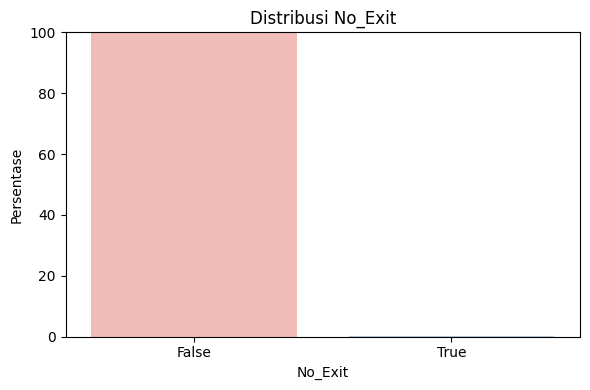


Distribusi untuk Railway:


,proportion
Railway,
False,0.99136
True,0.00864


  -> Tidak ada nilai dengan frekuensi sangat rendah di Railway.


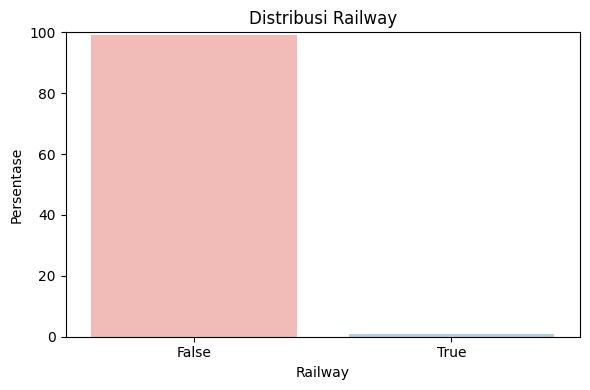


Distribusi untuk Roundabout:


,proportion
Roundabout,
False,0.999974
True,0.000026


  -> Potensi 'outlier' (nilai dengan frekuensi sangat rendah <0.01%) di Roundabout: [True]


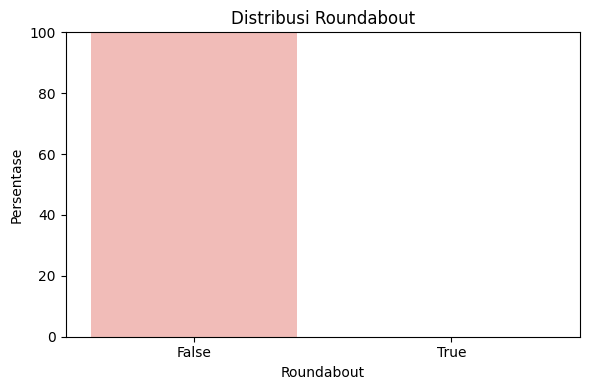


Distribusi untuk Station:


,proportion
Station,
False,0.974004
True,0.025996


  -> Tidak ada nilai dengan frekuensi sangat rendah di Station.


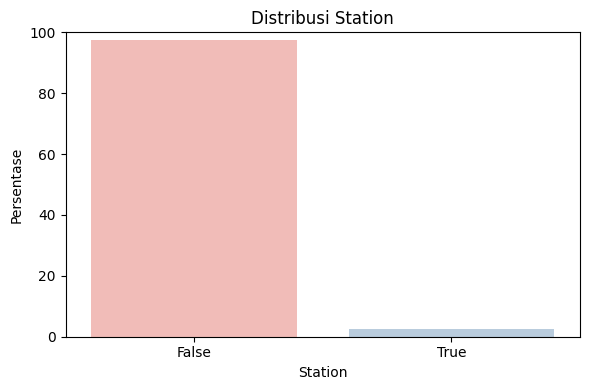


Distribusi untuk Stop:


,proportion
Stop,
False,0.971874
True,0.028126


  -> Tidak ada nilai dengan frekuensi sangat rendah di Stop.


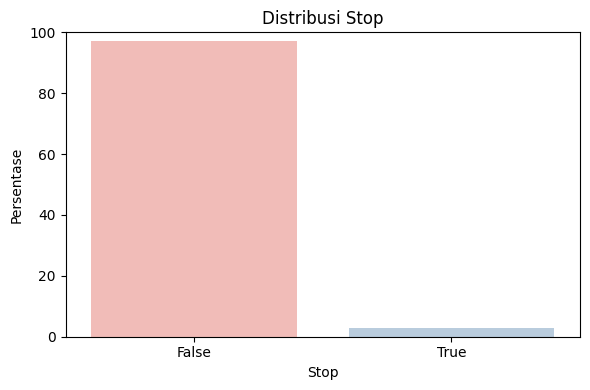


Distribusi untuk Traffic_Calming:


,proportion
Traffic_Calming,
False,0.999068
True,0.000932


  -> Tidak ada nilai dengan frekuensi sangat rendah di Traffic_Calming.


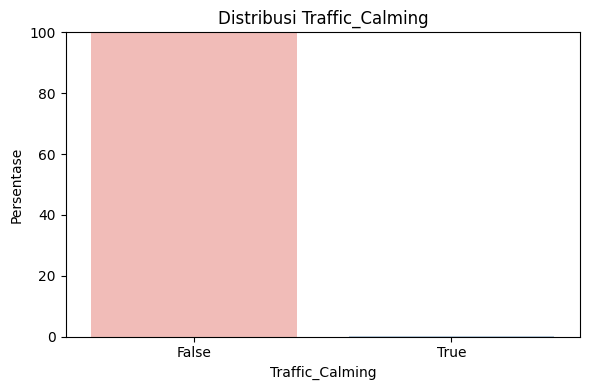


Distribusi untuk Traffic_Signal:


,proportion
Traffic_Signal,
False,0.85193
True,0.14807


  -> Tidak ada nilai dengan frekuensi sangat rendah di Traffic_Signal.


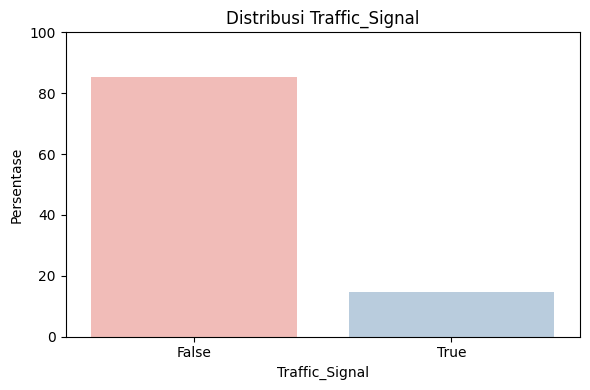


Distribusi untuk Turning_Loop:


,proportion
Turning_Loop,
False,1.0


  -> Tidak ada nilai dengan frekuensi sangat rendah di Turning_Loop.


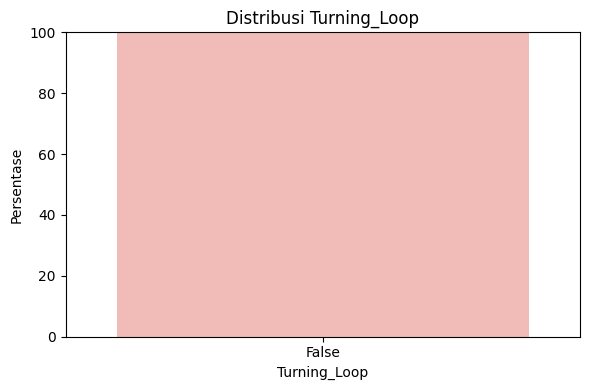

In [ ]:
boolean_features_for_outliers = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
    'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]

print("\nDeteksi Outlier pada Fitur Boolean (frekuensi rendah):")
for feature in boolean_features_for_outliers:
    value_counts = df_final_imputed[feature].value_counts(normalize=True)

    print(f"\nDistribusi untuk {feature}:")
    display(value_counts)

    # Identifikasi nilai dengan frekuensi sangat rendah (contoh: kurang dari 0.01%)
    low_frequency_values = value_counts[value_counts < 0.0001].index.tolist()

    if low_frequency_values:
        print(f"  -> Potensi 'outlier' (nilai dengan frekuensi sangat rendah <0.01%) di {feature}: {low_frequency_values}")
    else:
        print(f"  -> Tidak ada nilai dengan frekuensi sangat rendah di {feature}.")

    # Optional: Plot for better visualization if desired
    plt.figure(figsize=(6, 4))
    sns.barplot(x=value_counts.index.astype(str), y=value_counts.values * 100, palette='Pastel1')
    plt.title(f'Distribusi {feature}')
    plt.xlabel(feature)
    plt.ylabel('Persentase')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

## Pengecekan Data Duplikat

In [ ]:
duplicate_rows = df[df.duplicated()]

print(f"Jumlah baris duplikat: {len(duplicate_rows)}")

if not duplicate_rows.empty:
    print("Contoh baris duplikat pertama:")
    display(duplicate_rows.head())
else:
    print("Tidak ditemukan baris duplikat.")

Jumlah baris duplikat: 0
Tidak ditemukan baris duplikat.


# Analisis dengan Data Setelah Penanganan Missing Values (`df_final_imputed`)

In [ ]:
day_names_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

## Pola Waktu Kecelakaan (Menggunakan `df_final_imputed`)

In [ ]:
# Pastikan kolom waktu berformat datetime di df_final_imputed
df_final_imputed['Start_Time'] = pd.to_datetime(df_final_imputed['Start_Time'], errors='coerce')
df_final_imputed['End_Time'] = pd.to_datetime(df_final_imputed['End_Time'], errors='coerce')

# Ekstrak fitur waktu lagi dari df_final_imputed
df_final_imputed['Hour'] = df_final_imputed['Start_Time'].dt.hour
df_final_imputed['Day_of_Week'] = df_final_imputed['Start_Time'].dt.dayofweek
df_final_imputed['Month'] = df_final_imputed['Start_Time'].dt.month
df_final_imputed['Year'] = df_final_imputed['Start_Time'].dt.year

# Jam
hour_counts_imputed = df_final_imputed['Hour'].value_counts().sort_index()
hour_df_imputed = pd.DataFrame({'Hour': hour_counts_imputed.index, 'Count': hour_counts_imputed.values})
fig = px.bar(hour_df_imputed, x='Hour', y='Count',
             title='Kecelakaan berdasarkan Jam (df_final_imputed)',
             labels={'Hour': 'Jam', 'Count': 'Jumlah Kecelakaan'},
             color='Count',
             color_continuous_scale='YlOrRd')
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

# Hari
day_counts_imputed = df_final_imputed['Day_of_Week'].value_counts().sort_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_df_imputed = pd.DataFrame({'Day_of_Week_Num': day_counts_imputed.index, 'Count': day_counts_imputed.values})
day_df_imputed['Day_of_Week_Name'] = day_df_imputed['Day_of_Week_Num'].map(day_names_map)
fig = px.bar(day_df_imputed, x='Day_of_Week_Name', y='Count',
             title='Kecelakaan berdasarkan Hari (df_final_imputed)',
             labels={'Day_of_Week_Name': 'Hari', 'Count': 'Jumlah Kecelakaan'},
             color='Count',
             color_continuous_scale='YlOrRd')
fig.update_layout(xaxis={'categoryorder':'array', 'categoryarray': [day_names[i] for i in range(7)]})
fig.show()

# Bulan
month_counts_imputed = df_final_imputed['Month'].value_counts().sort_index()
month_names_full = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_df_imputed = pd.DataFrame({'Month_Num': month_counts_imputed.index, 'Count': month_counts_imputed.values})
month_df_imputed['Month_Name'] = month_df_imputed['Month_Num'].apply(lambda x: month_names_full[int(x)-1])
fig = px.bar(month_df_imputed, x='Month_Name', y='Count',
             title='Kecelakaan berdasarkan Bulan (df_final_imputed)',
             labels={'Month_Name': 'Bulan', 'Count': 'Jumlah Kecelakaan'},
             color='Count',
             color_continuous_scale='YlOrRd')
fig.update_layout(xaxis={'categoryorder':'array', 'categoryarray': month_names_full})
fig.show()

# Tahun
year_counts_imputed = df_final_imputed['Year'].value_counts().sort_index()
year_df_imputed = pd.DataFrame({'Year': year_counts_imputed.index, 'Count': year_counts_imputed.values})
fig = px.bar(year_df_imputed, x='Year', y='Count',
             title='Kecelakaan berdasarkan Tahun (df_final_imputed)',
             labels={'Year': 'Tahun', 'Count': 'Jumlah Kecelakaan'},
             color='Count',
             color_continuous_scale='YlOrRd')
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

In [ ]:
hourly_counts_imputed = df_final_imputed['Hour'].value_counts().sort_index()
dow_counts_imputed = df_final_imputed['Day_of_Week'].value_counts().sort_index()
monthly_counts_imputed = df_final_imputed['Month'].value_counts().sort_index()
year_counts_imputed = df_final_imputed['Year'].value_counts().sort_index()

peak_accident_info_imputed = {
    'Metric': ['Peak Hour', 'Peak Day', 'Peak Month', 'Peak Year'],
    'Value': [
        f"{hourly_counts_imputed.idxmax()}:00 ({hourly_counts_imputed.max():,} accidents)",
        f"{dow_counts_imputed.idxmax()} ({dow_counts_imputed.max():,} accidents)",
        f"{month_names[int(monthly_counts_imputed.idxmax())-1]} ({monthly_counts_imputed.max():,} accidents)",
        f"{year_counts_imputed.idxmax()} ({year_counts_imputed.max():,} accidents)"
    ]
}

print("\n Peak accident times (df_final_imputed):")
display(pd.DataFrame(peak_accident_info_imputed))


 Peak accident times (df_final_imputed):


,Metric,Value
0,Peak Hour,"7.0:00 (35,388 accidents)"
1,Peak Day,"4.0 (80,537 accidents)"
2,Peak Month,"December (48,897 accidents)"
3,Peak Year,"2021.0 (91,941 accidents)"


In [ ]:
# Ensure 'Start_Time' is datetime in df_capped
df_capped['Start_Time'] = pd.to_datetime(df_capped['Start_Time'], errors='coerce')

# Extract temporal features for df_capped
df_capped['Hour'] = df_capped['Start_Time'].dt.hour
df_capped['Day_of_Week'] = df_capped['Start_Time'].dt.dayofweek
df_capped['Month'] = df_capped['Start_Time'].dt.month
df_capped['Year'] = df_capped['Start_Time'].dt.year

# Calculate counts for capped data
hour_counts_capped = df_capped['Hour'].value_counts().sort_index()
day_counts_capped = df_capped['Day_of_Week'].value_counts().sort_index()
month_counts_capped = df_capped['Month'].value_counts().sort_index()
year_counts_capped = df_capped['Year'].value_counts().sort_index()

peak_accident_info_capped = {
    'Metric': ['Peak Hour', 'Peak Day', 'Peak Month', 'Peak Year'],
    'Value': [
        f"{hour_counts_capped.idxmax()}:00 ({hour_counts_capped.max():,} accidents)",
        f"{day_names_map[day_counts_capped.idxmax()]} ({day_counts_capped.max():,} accidents)",
        f"{month_names[int(month_counts_capped.idxmax())-1]} ({month_counts_capped.max():,} accidents)",
        f"{year_counts_capped.idxmax()} ({year_counts_capped.max():,} accidents)"
    ]
}

print("\n Peak accident times (df_capped):")
display(pd.DataFrame(peak_accident_info_capped))


 Peak accident times (df_capped):


,Metric,Value
0,Peak Hour,"7.0:00 (35,388 accidents)"
1,Peak Day,"Friday (80,537 accidents)"
2,Peak Month,"December (48,897 accidents)"
3,Peak Year,"2021.0 (91,941 accidents)"


## Lokasi Kecelakaan (Menggunakan `df_final_imputed`)

In [ ]:
state_counts_imputed = df_final_imputed['State'].value_counts().head(15)
state_df_imputed = pd.DataFrame({
    'State': state_counts_imputed.index,
    'Count': state_counts_imputed.values,
    'Persentase': (state_counts_imputed.values / len(df_final_imputed) * 100).round(2)
})
print("\n Top 15 States Berdasarkan Jumlah Kecelakaan (df_final_imputed):")
display(state_df_imputed)

print('\n')
fig_state_imputed = px.bar(
    state_df_imputed.head(10),
    x='Count',
    y='State',
    orientation='h',
    title="Top 10 States Berdasarkan Jumlah Kecelakaan (df_final_imputed)",
    labels={'Count': 'Jumlah Kecelakaan', 'State': 'State'},
    color='Count', # Map color to 'Count' for intensity
    color_continuous_scale='Reds' # Use a continuous red scale
)
fig_state_imputed.update_layout(height=500)
fig_state_imputed.show()

city_counts_imputed = df_final_imputed['City'].value_counts().head(15)
city_df_imputed = pd.DataFrame({
    'City': city_counts_imputed.index,
    'Count': city_counts_imputed.values,
    'Persentase': (city_counts_imputed.values / len(df_final_imputed) * 100).round(2)
})
print("\n Top 15 Kota Berdasarkan Jumlah Kecelakaan (df_final_imputed):")
display(city_df_imputed)

print('\n')
fig_city_imputed = px.bar(
    city_df_imputed.head(10),
    x='Count',
    y='City',
    orientation='h',
    title="Top 10 Kota Berdasarkan Jumlah Kecelakaan (df_final_imputed)",
    labels={'Count': 'Jumlah Kecelakaan', 'City': 'City'},
    color='Count', # Map color to 'Count' for intensity
    color_continuous_scale='Oranges' # Use a continuous orange scale
)
fig_city_imputed.update_layout(height=500)
fig_city_imputed.show()


 Top 15 States Berdasarkan Jumlah Kecelakaan (df_final_imputed):


,State,Count,Persentase
0,CA,113274,22.65
1,FL,56710,11.34
2,TX,37355,7.47
3,SC,24737,4.95
4,NY,22594,4.52
5,NC,21750,4.35
6,VA,19515,3.90
7,PA,19351,3.87
8,MN,12333,2.47
9,OR,11559,2.31



 Top 15 Kota Berdasarkan Jumlah Kecelakaan (df_final_imputed):


,City,Count,Persentase
0,Miami,12141,2.43
1,Houston,11031,2.21
2,Los Angeles,10299,2.06
3,Charlotte,8979,1.80
4,Dallas,8245,1.65
5,Orlando,6985,1.40
6,Austin,6269,1.25
7,Raleigh,5553,1.11
8,Nashville,4689,0.94
9,Baton Rouge,4625,0.92


In [ ]:
invalid_coords_imputed = df_final_imputed[(df_final_imputed['Start_Lat'].isna()) | (df_final_imputed['Start_Lng'].isna()) |
                   (df_final_imputed['Start_Lat'] == 0) | (df_final_imputed['Start_Lng'] == 0)]

coordinate_info_imputed = {
    'Metric': ['Latitude Range', 'Longitude Range', 'Invalid Coordinates Count', 'Invalid Coordinates Percentage'],
    'Value': [
        f"{df_final_imputed['Start_Lat'].min():.4f} to {df_final_imputed['Start_Lat'].max():.4f}",
        f"{df_final_imputed['Start_Lng'].min():.4f} to {df_final_imputed['Start_Lng'].max():.4f}",
        f"{len(invalid_coords_imputed):,}",
        f"{len(invalid_coords_imputed)/len(df_final_imputed)*100:.2f}%"
    ]
}

display(pd.DataFrame(coordinate_info_imputed))

,Metric,Value
0,Latitude Range,24.5621 to 48.9996
1,Longitude Range,-124.4974 to -67.4841
2,Invalid Coordinates Count,0
3,Invalid Coordinates Percentage,0.00%


## Cuaca Saat Kecelakaan (Menggunakan `df_final_imputed`)

In [ ]:
weather_counts_imputed = df_final_imputed['Weather_Condition'].value_counts().head(15)
weather_df_imputed = pd.DataFrame({
    'Weather_Condition': weather_counts_imputed.index,
    'Count': weather_counts_imputed.values,
    'Persentase': (weather_counts_imputed.values / len(df_final_imputed) * 100).round(2)
})
print("\n Top 15 Weather Conditions (df_final_imputed):")
display(weather_df_imputed)

print('\n')
fig_weather_imputed = px.bar(weather_df_imputed.head(10), y='Weather_Condition', x='Count',
             orientation='h',
             title=" Top 10 Weather Conditions Berdasarkan Jumlah Kecelakaan (df_final_imputed)",
             labels={'x': 'Jumlah Kecelakaan', 'y': 'Weather Condition'},
             color='Count', # Map color to 'Count' for intensity
             color_continuous_scale='Reds' # Use a continuous red scale
)
fig_weather_imputed.update_layout(height=500)
fig_weather_imputed.show()


 Top 15 Weather Conditions (df_final_imputed):


,Weather_Condition,Count,Persentase
0,Fair,166053,33.21
1,Mostly Cloudy,65398,13.08
2,Cloudy,53107,10.62
3,Clear,52379,10.48
4,Partly Cloudy,45125,9.02
5,Overcast,24901,4.98
6,Light Rain,22718,4.54
7,Scattered Clouds,13030,2.61
8,Unknown,11101,2.22
9,Light Snow,8233,1.65


In [ ]:
weather_features = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']
available_weather_imputed = [col for col in weather_features if col in df_final_imputed.columns]

if available_weather_imputed:
    print(f"\n Statistik Fitur Cuaca (df_final_imputed):")
    weather_stats_imputed = df_final_imputed[available_weather_imputed].describe()
    display(weather_stats_imputed.round(2))


 Statistik Fitur Cuaca (df_final_imputed):


,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph)
count,500000.0,500000.00,500000.00,500000.00
mean,61.7,64.88,9.11,7.63
std,18.8,22.57,2.68,5.23
min,-77.8,1.00,0.00,0.00
25%,50.0,49.00,10.00,5.00
50%,64.0,67.00,10.00,7.00
75%,76.0,84.00,10.00,10.00
max,207.0,100.00,130.00,822.80


## Kondisi Jalanan (Menggunakan `df_final_imputed`)

In [ ]:
road_features = ['Traffic_Signal', 'Crossing', 'Junction', 'Station',
                'Stop', 'Traffic_Calming', 'Turning_Loop', 'Roundabout', 'Amenity', 'Bump', 'Give_Way', 'No_Exit', 'Railway']
available_road_imputed = [col for col in road_features if col in df_final_imputed.columns]

if available_road_imputed:
    road_stats_list_imputed = []
    for feature in available_road_imputed:
        if df_final_imputed[feature].dtype == 'bool':
            true_count = df_final_imputed[feature].sum()
        else:
            true_count = (df_final_imputed[feature] == True).sum()

        true_pct = (true_count / len(df_final_imputed)) * 100
        road_stats_list_imputed.append({
            'Feature': feature,
            'Count': true_count,
            'Percentage': true_pct.round(2)
        })

    road_stats_df_imputed = pd.DataFrame(road_stats_list_imputed)
    print("\n Road Feature Presence (df_final_imputed):")
    display(road_stats_df_imputed)

    print('\n')
    if not road_stats_df_imputed.empty:
        fig_road_imputed = px.bar(road_stats_df_imputed.sort_values(by='Percentage', ascending=True),
                     x='Percentage',
                     y='Feature',
                     orientation='h',
                     title=" Road Feature Presence (%) (df_final_imputed)",
                     labels={'Percentage': 'Percentage of Accidents', 'Feature': 'Road Feature'},
                     color='Percentage', # Map color to 'Percentage' for intensity
                     color_continuous_scale='Oranges' # Use a continuous orange scale
)

        fig_road_imputed.update_layout(height=600, xaxis=dict(tickangle=45))
        fig_road_imputed.show()


 Road Feature Presence (df_final_imputed):


,Feature,Count,Percentage
0,Traffic_Signal,74035,14.81
1,Crossing,56253,11.25
2,Junction,37007,7.40
3,Station,12998,2.60
4,Stop,14063,2.81
5,Traffic_Calming,466,0.09
6,Turning_Loop,0,0.00
7,Roundabout,13,0.00
8,Amenity,6191,1.24
9,Bump,211,0.04


# Severity vs Waktu Kecelakaan

In [ ]:
peak_hour = hourly_counts.idxmax()
df_peak_hour_severity_counts = df[df['Hour'] == peak_hour].groupby('Severity').size().reset_index(name='Count')

fig = px.bar(df_peak_hour_severity_counts, x='Severity', y='Count',
             title=f'Severity Distribution at Peak Hour ({int(peak_hour)}:00)',
             labels={'Severity': 'Severity', 'Count': 'Number of Accidents'},
             color='Count',
             color_continuous_scale='YlOrRd')
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

In [ ]:
peak_day = dow_counts.idxmax()
df_peak_day_severity_counts = df[df['Day_of_Week'] == peak_day].groupby('Severity').size().reset_index(name='Count')

fig = px.bar(df_peak_day_severity_counts, x='Severity', y='Count',
             title=f'Severity Distribution on Peak Day (Day {int(peak_day)}: {day_names_map[int(peak_day)]})',
             labels={'Severity': 'Severity', 'Count': 'Number of Accidents'},
             color='Count',
             color_continuous_scale='YlOrRd')
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

In [ ]:
peak_month = monthly_counts.idxmax()
df_peak_month_severity_counts = df[df['Month'] == peak_month].groupby('Severity').size().reset_index(name='Count')

fig = px.bar(df_peak_month_severity_counts, x='Severity', y='Count',
             title=f'Severity Distribution on Peak Month ({month_names[int(peak_month)-1]})',
             labels={'Severity': 'Severity', 'Count': 'Number of Accidents'},
             color='Count',
             color_continuous_scale='YlOrRd')
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

In [ ]:
peak_year = year_counts.idxmax()
df_peak_year_severity_counts = df[df['Year'] == peak_year].groupby('Severity').size().reset_index(name='Count')

fig = px.bar(df_peak_year_severity_counts, x='Severity', y='Count',
             title=f'Severity Distribution on Peak Year ({int(peak_year)})',
             labels={'Severity': 'Severity', 'Count': 'Number of Accidents'},
             color='Count',
             color_continuous_scale='YlOrRd')
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

# Severity vs Top 10 State

In [ ]:
top_10_state = df['State'].value_counts().head(10).index

for state in top_10_state:
    df_state = df[df['State'] == state]
    severity_counts_state = df_state['Severity'].value_counts().sort_index() # Sort by severity level, not count

    severity_df_state = pd.DataFrame({'Severity': severity_counts_state.index, 'Count': severity_counts_state.values})

    fig = px.bar(severity_df_state, x='Severity', y='Count',
                 title=f'Severity Distribution in {state}',
                 labels={'Severity': 'Severity', 'Count': 'Number of Accidents'},
                 color='Count', # Map color to 'Count' for intensity
                 color_continuous_scale='YlOrRd')
    fig.update_layout(xaxis={'categoryorder':'category ascending'})
    fig.show()

# Severity vs Top 10 Weather

In [ ]:
top_10_weather = df['Weather_Condition'].value_counts().head(10).index

for weather in top_10_weather:
    df_weather = df[df['Weather_Condition'] == weather]
    severity_counts_weather = df_weather['Severity'].value_counts().sort_index()

    severity_df_weather = pd.DataFrame({'Severity': severity_counts_weather.index, 'Count': severity_counts_weather.values})

    fig = px.bar(severity_df_weather, x='Severity', y='Count',
                 title=f'Severity Distribution during {weather}',
                 labels={'Severity': 'Severity', 'Count': 'Number of Accidents'},
                 color='Count',
                 color_continuous_scale='YlOrRd')
    fig.update_layout(xaxis={'categoryorder':'category ascending'})
    fig.show()

# Severity vs 10 City

In [ ]:
top10_cities = df['City'].value_counts().head(10).index

for city in top10_cities:
    df_city = df[df['City'] == city]
    severity_counts_city = df_city['Severity'].value_counts().sort_index()

    severity_df_city = pd.DataFrame({'Severity': severity_counts_city.index, 'Count': severity_counts_city.values})

    fig = px.bar(severity_df_city, x='Severity', y='Count',
                 title=f'Severity Distribution in {city}',
                 labels={'Severity': 'Severity', 'Count': 'Number of Accidents'},
                 color='Count',
                 color_continuous_scale='YlOrRd')
    fig.update_layout(xaxis={'categoryorder':'category ascending'})
    fig.show()

# Severity vs Traffic Signal

In [ ]:
traffic_signal_severity_counts = df.groupby(['Traffic_Signal', 'Severity']).size().reset_index(name='Count')

fig = px.bar(traffic_signal_severity_counts, x='Traffic_Signal', y='Count', color='Severity',
             title='Severity Distribution vs Traffic Signal',
             labels={'Traffic_Signal': 'Traffic Signal (False/True)', 'Count': 'Jumlah Kecelakaan'},
             color_discrete_sequence=px.colors.sequential.YlOrRd)
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

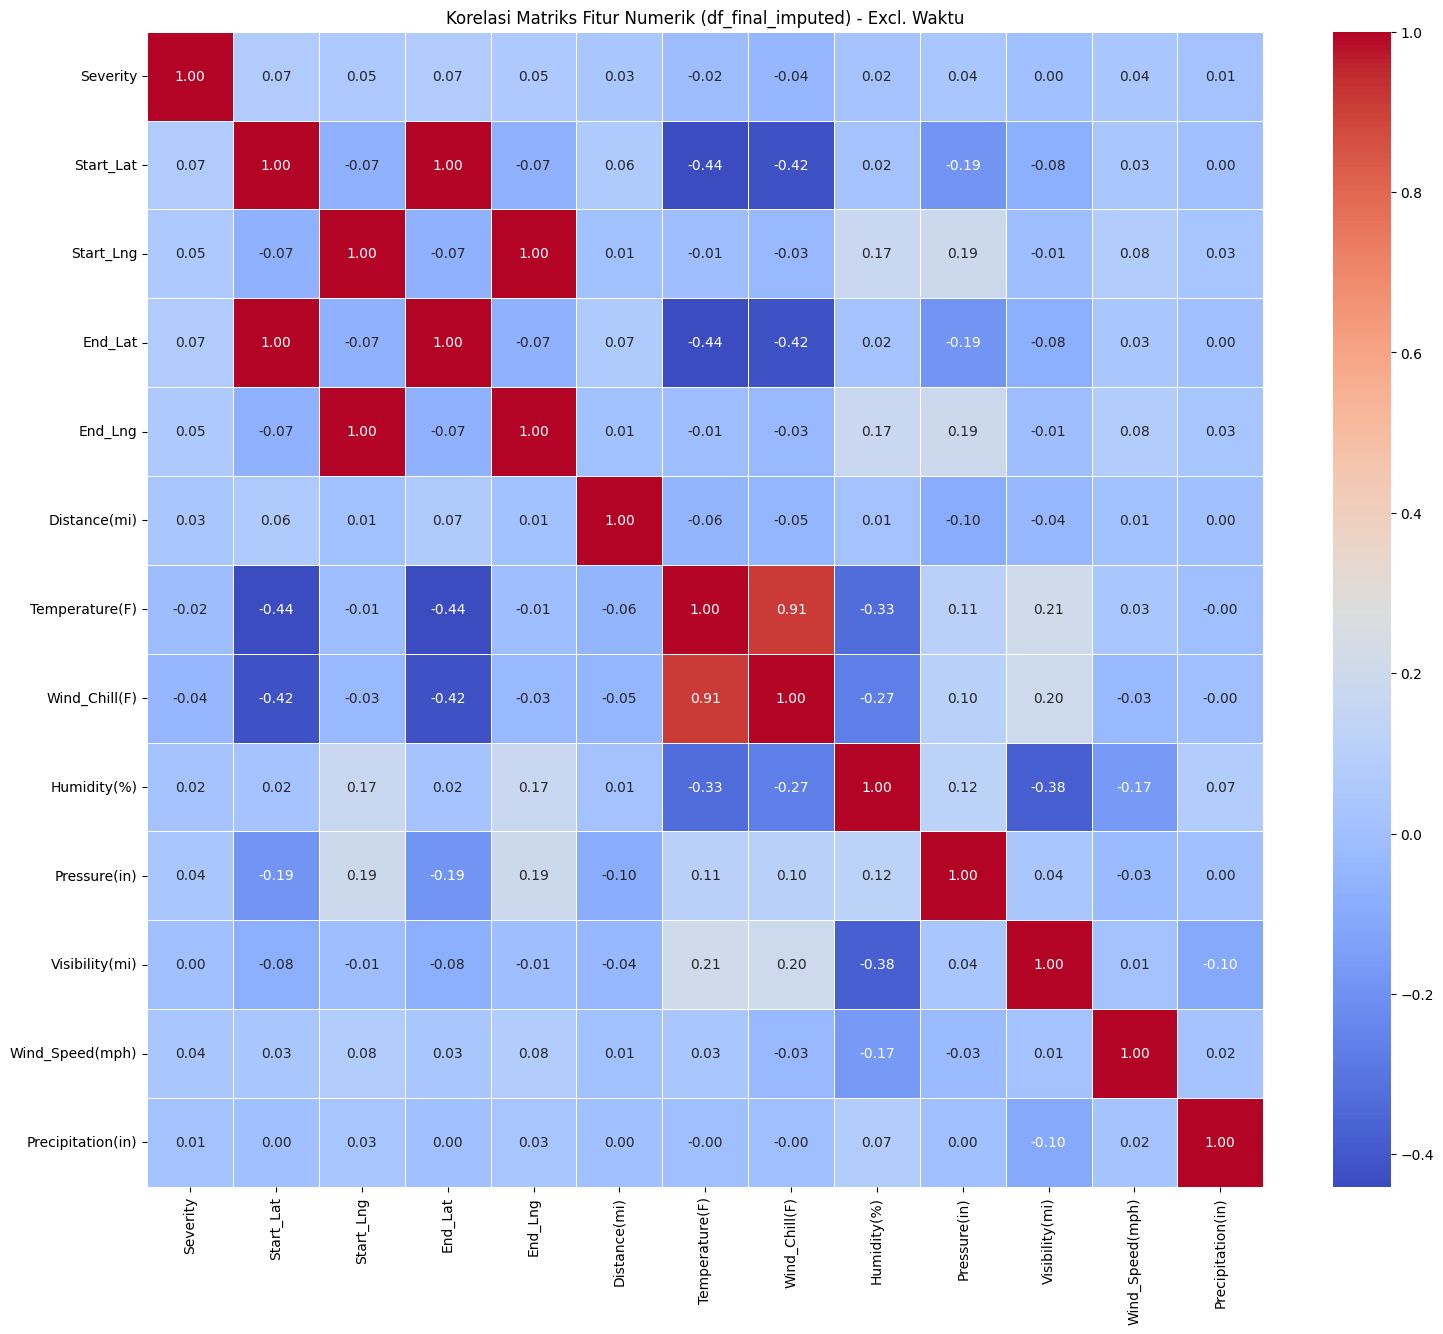

In [ ]:
# Korelasi Matriks

numerical_features = df_final_imputed.select_dtypes(include=['float64', 'int64']).columns

features_to_exclude = ['Hour', 'Day_of_Week', 'Month', 'Year']
numerical_features = [f for f in numerical_features if f not in features_to_exclude]

correlation_matrix = df_final_imputed[numerical_features].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Korelasi Matriks Fitur Numerik (df_final_imputed) - Excl. Waktu')
plt.show()

# modeling/predictive

In [ ]:
!pip install imbalanced-learn xgboost -q

Shape data setelah feature selection: (451837, 27)

Distribusi Severity (sebelum SMOTE):
Severity
1      4274
2    351251
3     84513
4     11799
Name: count, dtype: int64

Ukuran data latih : (361469, 26)
Ukuran data uji   : (90368, 26)

===== TRAINING MODELS WITHOUT SMOTE =====

[1/2] Melatih Random Forest (tanpa SMOTE)...
Random Forest (tanpa SMOTE) selesai dilatih.

[2/2] Melatih XGBoost (tanpa SMOTE)...
XGBoost (tanpa SMOTE) selesai dilatih.

===== APPLYING SMOTE =====

Distribusi Severity setelah SMOTE:
Severity
1    281001
2    281001
3    281001
4    281001
Name: count, dtype: int64

===== TRAINING MODELS WITH SMOTE =====

[1/2] Melatih Random Forest (dengan SMOTE)...
Random Forest (dengan SMOTE) selesai dilatih.

[2/2] Melatih XGBoost (dengan SMOTE)...
XGBoost (dengan SMOTE) selesai dilatih.

===== EVALUATION WITHOUT SMOTE =====

  RANDOM FOREST (No SMOTE)
  Accuracy    : 0.7943 (79.43%%)
  Macro F1    : 0.3768

  Classification Report:
              precision    recall  f1-sc

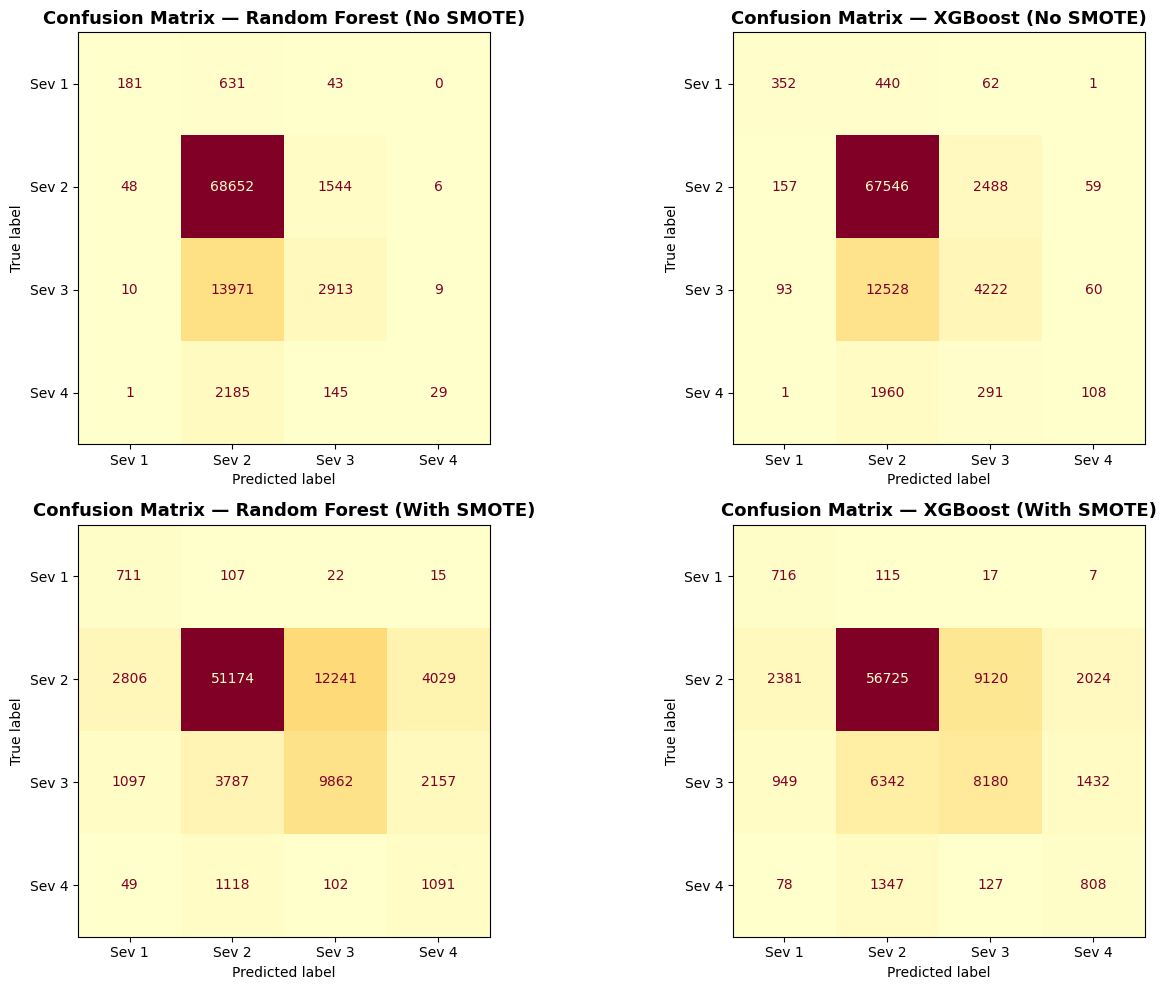

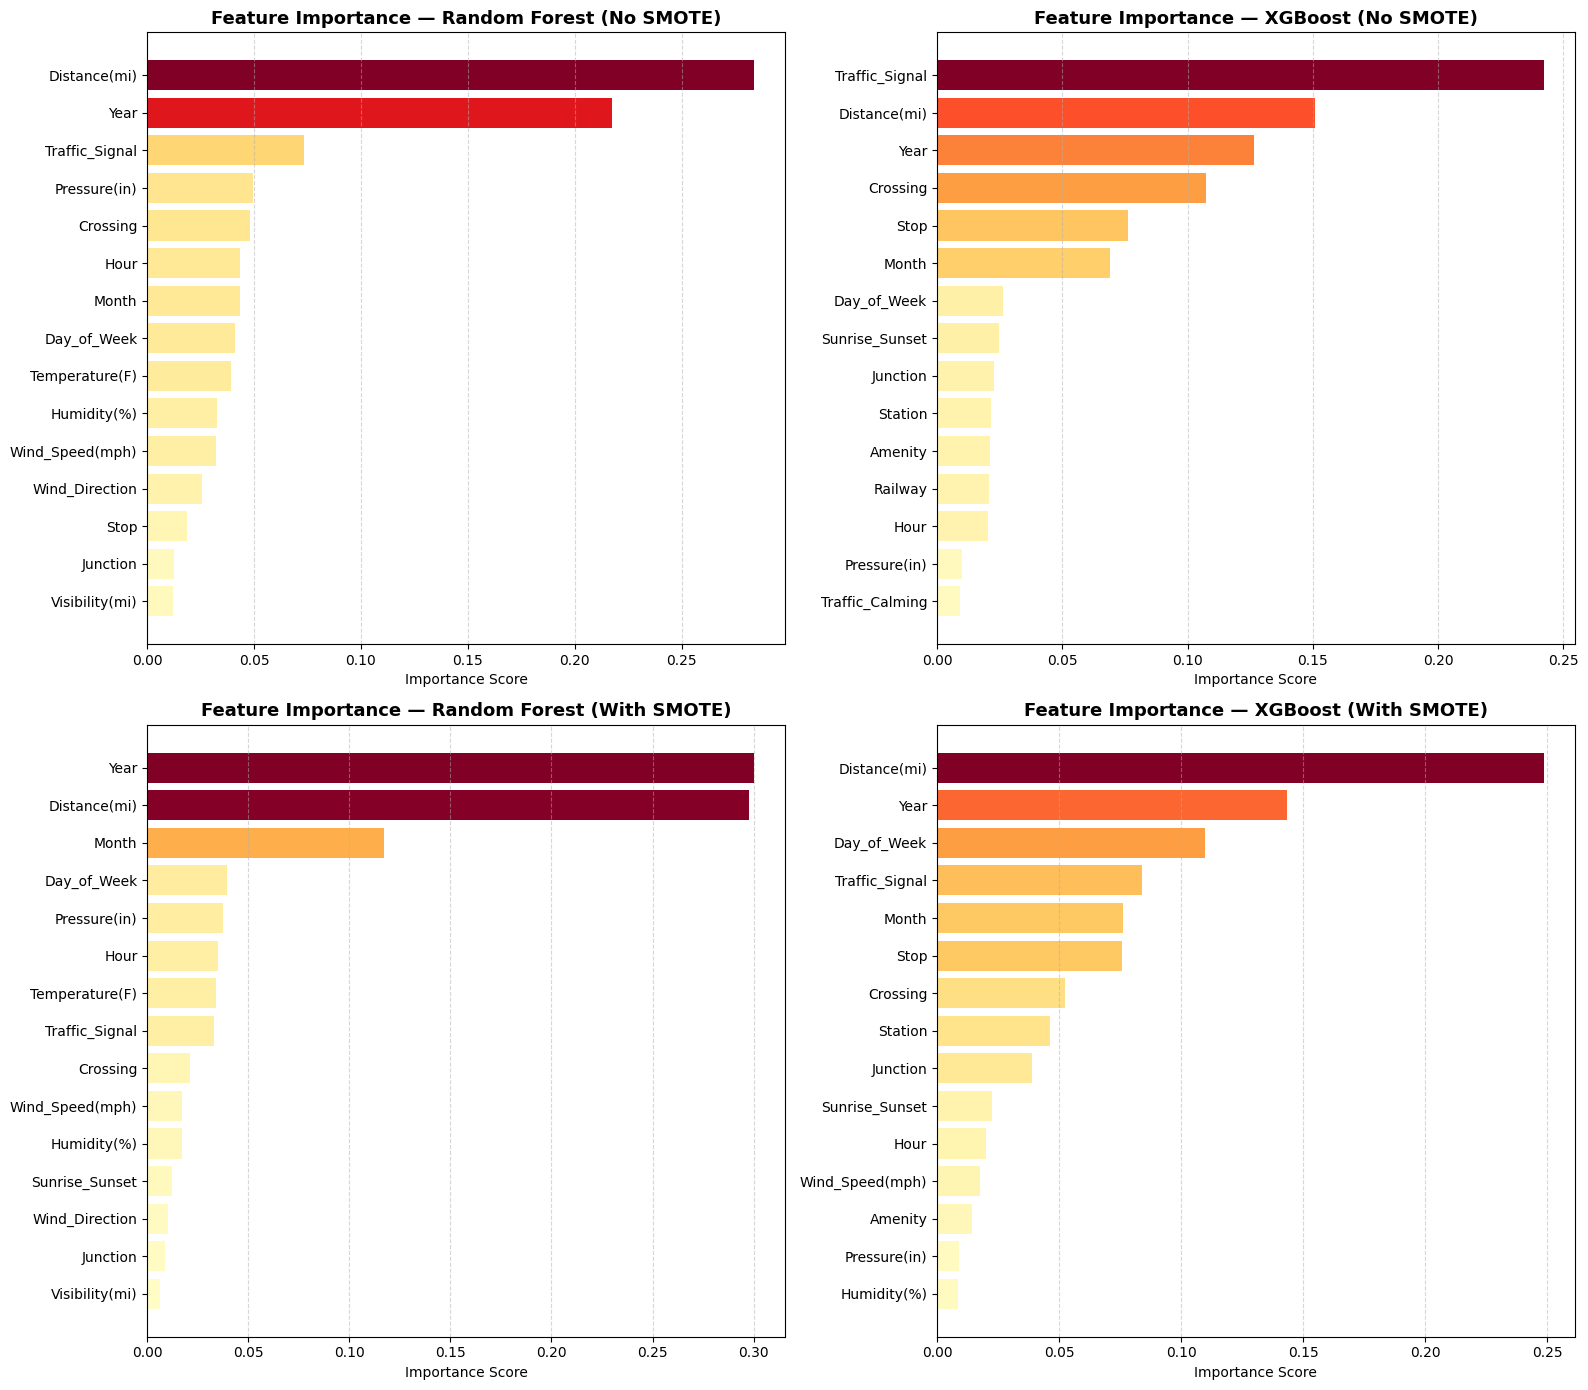


 RINGKASAN PERFORMA MODEL


,Accuracy,Macro F1,F1 Sev-1,F1 Sev-2,F1 Sev-3,F1 Sev-4
Model,,,,,,
Random Forest (No SMOTE),0.7943,0.3768,0.3306,0.8819,0.2704,0.0241
XGBoost (No SMOTE),0.7993,0.4508,0.4829,0.8845,0.3523,0.0835
Random Forest (With SMOTE),0.6954,0.4493,0.2577,0.8095,0.5041,0.2261
XGBoost (With SMOTE),0.7351,0.4623,0.2876,0.8417,0.4763,0.2437


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PREDICTIVE MODELING — Random Forest & XGBoost
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb


# 1. FEATURE SELECTION
# Fitur numerik cuaca & jarak
numerical_features = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Pressure(in)', 'Precipitation(in)', 'Distance(mi)'
]

# Fitur temporal (sudah diekstrak sebelumnya)
temporal_features = ['Hour', 'Day_of_Week', 'Month', 'Year']

# Fitur infrastruktur jalan (boolean → int)
road_features = [
    'Traffic_Signal', 'Crossing', 'Junction', 'Stop',
    'Station', 'Amenity', 'Railway', 'Give_Way', 'Roundabout',
    'Bump', 'Traffic_Calming', 'No_Exit', 'Turning_Loop'
]

# Fitur kategorikal yang di-encode
categorical_features = ['Sunrise_Sunset', 'Wind_Direction']

# Gabungkan semua fitur
all_features = numerical_features + temporal_features + road_features + categorical_features
target = 'Severity'

# Buat dataframe fitur
df_model = df_final_imputed[all_features + [target]].copy()

# Encode boolean → int
for col in road_features:
    df_model[col] = df_model[col].astype(int)

# Encode kategorikal dengan LabelEncoder
le = LabelEncoder()
for col in categorical_features:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Drop baris yang masih ada NaN (jika ada)
df_model.dropna(inplace=True)

print(f"Shape data setelah feature selection: {df_model.shape}")
print(f"\nDistribusi Severity (sebelum SMOTE):")
print(df_model[target].value_counts().sort_index())

# 2. TRAIN-TEST SPLIT
X = df_model[all_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nUkuran data latih : {X_train.shape}")
print(f"Ukuran data uji   : {X_test.shape}")

# 3. TRAINING MODEL (NO SMOTE) ──────────────────

print("\n===== TRAINING MODELS WITHOUT SMOTE =====")

# --- Random Forest (No SMOTE) ---
print("\n[1/2] Melatih Random Forest (tanpa SMOTE)...")
rf_model_no_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model_no_smote.fit(X_train, y_train)
rf_pred_no_smote = rf_model_no_smote.predict(X_test)
print("Random Forest (tanpa SMOTE) selesai dilatih.")

# --- XGBoost (No SMOTE) ---
print("\n[2/2] Melatih XGBoost (tanpa SMOTE)...")
xgb_model_no_smote = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
# XGBoost butuh label mulai dari 0
y_train_xgb_no_smote = y_train - 1

xgb_model_no_smote.fit(X_train, y_train_xgb_no_smote)
xgb_pred_no_smote = xgb_model_no_smote.predict(X_test) + 1  # kembalikan ke 1-4
print("XGBoost (tanpa SMOTE) selesai dilatih.")

# 4. SMOTE ─ Penanganan Class Imbalance ─────────────
print("\n===== APPLYING SMOTE =====")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nDistribusi Severity setelah SMOTE:")
print(pd.Series(y_train_sm).value_counts().sort_index())

# 5. TRAINING MODEL (WITH SMOTE) ───────────────

print("\n===== TRAINING MODELS WITH SMOTE =====")

# --- Random Forest (with SMOTE) ---
print("\n[1/2] Melatih Random Forest (dengan SMOTE)...")
rf_model_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model_smote.fit(X_train_sm, y_train_sm)
rf_pred_smote = rf_model_smote.predict(X_test)
print("Random Forest (dengan SMOTE) selesai dilatih.")

# --- XGBoost (with SMOTE) ---
print("\n[2/2] Melatih XGBoost (dengan SMOTE)...")
xgb_model_smote = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
# XGBoost butuh label mulai dari 0
y_train_xgb_smote  = y_train_sm - 1

xgb_model_smote.fit(X_train_sm, y_train_xgb_smote)
xgb_pred_smote = xgb_model_smote.predict(X_test) + 1  # kembalikan ke 1-4
print("XGBoost (dengan SMOTE) selesai dilatih.")

# 6. EVALUASI MODEL ──────────────────────────────

def print_evaluation(name, y_true, y_pred):
    acc     = accuracy_score(y_true, y_pred)
    macro_f1= f1_score(y_true, y_pred, average='macro')
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy    : {acc:.4f} ({acc*100:.2f}%%)")
    print(f"  Macro F1    : {macro_f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

print("\n===== EVALUATION WITHOUT SMOTE =====")
print_evaluation("RANDOM FOREST (No SMOTE)", y_test, rf_pred_no_smote)
print_evaluation("XGBOOST (No SMOTE)",       y_test, xgb_pred_no_smote)

print("\n===== EVALUATION WITH SMOTE =====")
print_evaluation("RANDOM FOREST (With SMOTE)", y_test, rf_pred_smote)
print_evaluation("XGBOOST (With SMOTE)",       y_test, xgb_pred_smote)

# 7. CONFUSION MATRIX ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, pred) in enumerate([("Random Forest (No SMOTE)", rf_pred_no_smote),
                                   ("XGBoost (No SMOTE)", xgb_pred_no_smote),
                                   ("Random Forest (With SMOTE)", rf_pred_smote),
                                   ("XGBoost (With SMOTE)", xgb_pred_smote)]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Sev 1','Sev 2','Sev 3','Sev 4'])
    disp.plot(ax=axes[i], colorbar=False, cmap='YlOrRd')
    axes[i].set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. FEATURE IMPORTANCE ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (name, model) in enumerate([("Random Forest (No SMOTE)", rf_model_no_smote),
                                   ("XGBoost (No SMOTE)", xgb_model_no_smote),
                                   ("Random Forest (With SMOTE)", rf_model_smote),
                                   ("XGBoost (With SMOTE)", xgb_model_smote)]):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

    axes[i].barh(fi_df['Feature'], fi_df['Importance'],
            color=plt.cm.YlOrRd(fi_df['Importance'] / fi_df['Importance'].max()))
    axes[i].set_title(f'Feature Importance — {name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Importance Score')
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. RINGKASAN PERFORMA ────────────────────
summary = pd.DataFrame({
    'Model'     : [
        'Random Forest (No SMOTE)', 'XGBoost (No SMOTE)',
        'Random Forest (With SMOTE)', 'XGBoost (With SMOTE)'
    ],
    'Accuracy'  : [
        accuracy_score(y_test, rf_pred_no_smote),
        accuracy_score(y_test, xgb_pred_no_smote),
        accuracy_score(y_test, rf_pred_smote),
        accuracy_score(y_test, xgb_pred_smote)
    ],
    'Macro F1'  : [
        f1_score(y_test, rf_pred_no_smote, average='macro'),
        f1_score(y_test, xgb_pred_no_smote, average='macro'),
        f1_score(y_test, rf_pred_smote, average='macro'),
        f1_score(y_test, xgb_pred_smote, average='macro')
    ],
    'F1 Sev-1'  : [
        f1_score(y_test, rf_pred_no_smote,  average=None)[0],
        f1_score(y_test, xgb_pred_no_smote, average=None)[0],
        f1_score(y_test, rf_pred_smote,  average=None)[0],
        f1_score(y_test, xgb_pred_smote, average=None)[0]
    ],
    'F1 Sev-2'  : [
        f1_score(y_test, rf_pred_no_smote,  average=None)[1],
        f1_score(y_test, xgb_pred_no_smote, average=None)[1],
        f1_score(y_test, rf_pred_smote,  average=None)[1],
        f1_score(y_test, xgb_pred_smote, average=None)[1]
    ],
    'F1 Sev-3'  : [
        f1_score(y_test, rf_pred_no_smote,  average=None)[2],
        f1_score(y_test, xgb_pred_no_smote, average=None)[2],
        f1_score(y_test, rf_pred_smote,  average=None)[2],
        f1_score(y_test, xgb_pred_smote, average=None)[2]
    ],
    'F1 Sev-4'  : [
        f1_score(y_test, rf_pred_no_smote,  average=None)[3],
        f1_score(y_test, xgb_pred_no_smote, average=None)[3],
        f1_score(y_test, rf_pred_smote,  average=None)[3],
        f1_score(y_test, xgb_pred_smote, average=None)[3]
    ],
})

summary = summary.set_index('Model').round(4)
print("\n RINGKASAN PERFORMA MODEL")
display(summary)